# House Price Prediction Project
**Goal:** We want to build an AI model that looks at house details (like area, rooms) and predicts its final `SalePrice`.

### Phase 1: What we have done so far?
1. **Created a Project Folder:** Set up the environment using `uv`.
2. **Downloaded Data:** Got the official `train.csv` and `test.csv` files from Kaggle.
   - **Train Data:** Contains house details AND the final price (AI learns from this).
   - **Test Data:** Contains house details but NO price (AI will guess this later).
3. **Loaded Libraries & Data:** Brought our data into Python using Pandas.

In [ ]:
import calendar

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pandas.api.types import CategoricalDtype
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', None)

print("All tools are ready")

All tools are ready


In [216]:
# ==========================================
# STEP 2: LOADING THE CSV FILES
# ==========================================

train_path = "/content/train.csv"
test_path = "/content/test.csv"

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

print(f"Shape of df_train: {df_train.shape}")
print(f"Shape of df_test:  {df_test.shape}")

Shape of df_train: (1460, 81)
Shape of df_test:  (1459, 80)


In [106]:
# Display all columns without hiding any (Safe & Recommended)
pd.set_option("display.max_columns", None)

In [107]:
df_train.head() # Display the first few rows of the training dataset

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [108]:
df_test.head()
# Display the first few rows of the test dataset


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,6,1998,1998,Gable,CompShg,VinylSd,VinylSd,BrkFace,20.0,TA,TA,PConc,TA,TA,No,GLQ,602.0,Unf,0.0,324.0,926.0,GasA,Ex,Y,SBrkr,926,678,0,1604,0.0,0.0,2,1,3,1,Gd,7,Typ,1,Gd,Attchd,1998.0,Fin,2.0,470.0,TA,TA,Y,360,36,0,0,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,Gtl,StoneBr,Norm,Norm,TwnhsE,1Story,8,5,1992,1992,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,Gd,TA,PConc,Gd,TA,No,ALQ,263.0,Unf,0.0,1017.0,1280.0,GasA,Ex,Y,SBrkr,1280,0,0,1280,0.0,0.0,2,0,2,1,Gd,5,Typ,0,NaN,Attchd,1992.0,RFn,2.0,506.0,TA,TA,Y,0,82,0,0,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


# Data Preprocessing: Importance and Techniques

Ensuring data quality is crucial for robust model performance. Preprocessing involves:

- Handling missing values
- Correcting data types
- Removing irrelevant features

### Key Features Impacting SalePrice:

1.  **OverallQual**: Overall material and finish quality (1-10).
2.  **GrLivArea**: Above grade (ground) living area square feet.
3.  **YearBuilt**: Original construction date.
4.  **Neighborhood**: Physical locations within Ames city limits.
5.  **GarageCars**: Size of garage in car capacity.
6.  **FullBath**: Full bathrooms above grade.
7.  **TotalBsmtSF**: Total square feet of basement area.
8.  **KitchenQual**: Kitchen quality (Excellent to Poor).

# 🔑 Essential DataFrame Inspection Methods (The 80/20 Rule)

When beginning Exploratory Data Analysis (EDA) in **pandas**, these four commands provide the majority of the initial structural insights needed to understand your dataset.

## 1. `df.shape` — Dataset Dimensions
* **Type:** Attribute (no parentheses `()`)
* **Purpose:** Returns a tuple indicating the number of rows and columns: `(rows, columns)`.
* **Interpretation:** An output like `(1460, 81)` means the dataset contains **1,460 rows (records)** and **81 columns (features)**.

## 2. `df.columns` — Feature Names
* **Type:** Attribute (no parentheses `()`)
* **Purpose:** Returns an `Index` object containing all column names.
* **Interpretation:** Use this to verify exact column naming conventions, capitalization, and whitespace.

## 3. `df.head(n=5)` — Preview Initial Records
* **Type:** Method
* **Purpose:** Returns the first `n` rows of the DataFrame (default is `5`).
* **Interpretation:** Provides a quick visual inspection of the actual data values and format.

## 4. `df.info()` — Data Types & Missing Values
* **Type:** Method
* **Purpose:** Prints a concise summary including total entries, column data types (`dtypes`), and non-null (non-missing) counts.
* **Interpretation:** Essential for spotting **missing values** and detecting incorrect data types (e.g., numbers stored as strings).

---

### 📋 Quick Reference Summary

| Command | Type | Purpose | Primary Output |
| :--- | :--- | :--- | :--- |
| `df.shape` | Attribute | Check size | `(rows, columns)` tuple |
| `df.columns` | Attribute | View feature names | Array of column labels |
| `df.head(n)` | Method | Inspect data sample | First `n` rows (default: 5) |
| `df.info()` | Method | Check dtypes & nulls | Summary report |

# Exploratory Data Analysis (EDA)

Understanding data patterns and relationships with `SalePrice` is critical for model development.

### Key EDA steps:

- Analyze `SalePrice` distribution (mean, min, max).
- Identify correlations between numerical features and `SalePrice`.
- Assess the impact of categorical features (e.g., `Neighborhood`, `HouseStyle`) on `SalePrice`.

## Key Features for Encoding

The following features will be utilized for numerical conversion/encoding:
1. Neighborhood
2. Overall Qual
3. YearBuilt
4. Foundation
5. Electrical
6. KitchenQual
7. GarageType
8. GarageFinish
9. Fence

## Data-Integration

In [109]:
df = pd.concat([df_train, df_test])

print(f"Shape of integrated dataframe: {df.shape}")

Shape of integrated dataframe: (2919, 81)


In [110]:
df.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706.0,Unf,0.0,150.0,856.0,GasA,Ex,Y,SBrkr,856,854,0,1710,1.0,0.0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2.0,548.0,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500.0
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978.0,Unf,0.0,284.0,1262.0,GasA,Ex,Y,SBrkr,1262,0,0,1262,0.0,1.0,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2.0,460.0,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.0
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486.0,Unf,0.0,434.0,920.0,GasA,Ex,Y,SBrkr,920,866,0,1786,1.0,0.0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2.0,608.0,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500.0
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216.0,Unf,0.0,540.0,756.0,GasA,Gd,Y,SBrkr,961,756,0,1717,1.0,0.0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3.0,642.0,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.0
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655.0,Unf,0.0,490.0,1145.0,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1.0,0.0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3.0,836.0,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000.0


In [111]:
df.tail() # see the last line of the combined dataframe

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1454,2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,Twnhs,2Story,4,7,1970,1970,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Unf,0.0,Unf,0.0,546.0,546.0,GasA,Gd,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,5,Typ,0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal,NaN
1455,2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,TwnhsE,2Story,4,5,1970,1970,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,252.0,Unf,0.0,294.0,546.0,GasA,TA,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,6,Typ,0,NaN,CarPort,1970.0,Unf,1.0,286.0,TA,TA,Y,0,24,0,0,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml,NaN
1456,2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1Story,5,7,1960,1996,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,ALQ,1224.0,Unf,0.0,0.0,1224.0,GasA,Ex,Y,SBrkr,1224,0,0,1224,1.0,0.0,1,0,4,1,TA,7,Typ,1,TA,Detchd,1960.0,Unf,2.0,576.0,TA,TA,Y,474,0,0,0,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml,NaN
1457,2918,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,SFoyer,5,5,1992,1992,Gable,CompShg,HdBoard,Wd Shng,NaN,0.0,TA,TA,PConc,Gd,TA,Av,GLQ,337.0,Unf,0.0,575.0,912.0,GasA,TA,Y,SBrkr,970,0,0,970,0.0,1.0,1,0,3,1,TA,6,Typ,0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,Y,80,32,0,0,0,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal,NaN
1458,2919,60,RL,74.0,9627,Pave,NaN,Reg,Lvl,AllPub,Inside,Mod,Mitchel,Norm,Norm,1Fam,2Story,7,5,1993,1994,Gable,CompShg,HdBoard,HdBoard,BrkFace,94.0,TA,TA,PConc,Gd,TA,Av,LwQ,758.0,Unf,0.0,238.0,996.0,GasA,Ex,Y,SBrkr,996,1004,0,2000,0.0,0.0,2,1,3,1,TA,9,Typ,1,TA,Attchd,1993.0,Fin,3.0,650.0,TA,TA,Y,190,48,0,0,0,0,NaN,NaN,NaN,0,11,2006,WD,Normal,NaN


## Get a Brief Overview of the Dataset

In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2919 entries, 0 to 1458
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             2919 non-null   int64  
 1   MSSubClass     2919 non-null   int64  
 2   MSZoning       2915 non-null   object 
 3   LotFrontage    2433 non-null   float64
 4   LotArea        2919 non-null   int64  
 5   Street         2919 non-null   object 
 6   Alley          198 non-null    object 
 7   LotShape       2919 non-null   object 
 8   LandContour    2919 non-null   object 
 9   Utilities      2917 non-null   object 
 10  LotConfig      2919 non-null   object 
 11  LandSlope      2919 non-null   object 
 12  Neighborhood   2919 non-null   object 
 13  Condition1     2919 non-null   object 
 14  Condition2     2919 non-null   object 
 15  BldgType       2919 non-null   object 
 16  HouseStyle     2919 non-null   object 
 17  OverallQual    2919 non-null   int64  
 18  OverallCond  

In [113]:
# Select only the columns that have 'int64' (integer) data type

int_feature = df.select_dtypes(include=['int64']).columns

# Print the total count of these integer columns
print(f"The total number of integer column is: {int_feature.shape[0]}")

#Print the actual names of these columns to check for traps!
print("\nList of integer columns:")
print(int_feature.tolist())  # .tolist() makes it easier to read


The total number of integer column is: 26

List of integer columns:
['Id', 'MSSubClass', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold']


In [114]:
# Select only the columns that have 'float64' (floating point) data type

float_feature = df.select_dtypes(include=['float64']).columns

# Print the total count of these float columns
print(f"The total number of float column is: {float_feature.shape[0]}")

#Print the actual names of these columns to check for traps!
print("\nList of float columns:")
print(float_feature.tolist())  # .tolist() makes it easier to read


The total number of float column is: 12

List of float columns:
['LotFrontage', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'SalePrice']


In [115]:
# Select only the columns that have 'object' (string) data type

object_feature = df.select_dtypes(include=['object', 'string']).columns

# Print the total count of these object columns
print(f"The total number of categorical column is: {object_feature.shape[0]}")

#Print the actual names of these columns to check for traps!
print("\nList of categorical columns:")
print(object_feature.tolist())  # .tolist() makes it easier to read

The total number of categorical column is: 43

List of categorical columns:
['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


## Get the Statistical Information of Numerical Features

In [116]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,2919.000000,2919.000000,2433.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2896.000000,2918.000000,2918.000000,2918.000000,2918.000000,2919.000000,2919.000000,2919.000000,2919.000000,2917.000000,2917.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2760.000000,2918.000000,2918.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,2919.000000,1460.000000
mean,1460.000000,57.137718,69.305795,10168.114080,6.089072,5.564577,1971.312778,1984.264474,102.201312,441.423235,49.582248,560.772104,1051.777587,1159.581706,336.483727,4.694416,1500.759849,0.429894,0.061364,1.568003,0.380267,2.860226,1.044536,6.451524,0.597122,1978.113406,1.766621,472.874572,93.709832,47.486811,23.098321,2.602261,16.062350,2.251799,50.825968,6.213087,2007.792737,180921.195890
std,842.787043,42.517628,23.344905,7886.996359,1.409947,1.113131,30.291442,20.894344,179.334253,455.610826,169.205611,439.543659,440.766258,392.362079,428.701456,46.396825,506.051045,0.524736,0.245687,0.552969,0.502872,0.822693,0.214462,1.569379,0.646129,25.574285,0.761624,215.394815,126.526589,67.575493,64.244246,25.188169,56.184365,35.663946,567.402211,2.714762,1.314964,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,1895.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,730.500000,20.000000,59.000000,7478.000000,5.000000,5.000000,1953.500000,1965.000000,0.000000,0.000000,0.000000,220.000000,793.000000,876.000000,0.000000,0.000000,1126.000000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,5.000000,0.000000,1960.000000,1.000000,320.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000,129975.000000
50%,1460.000000,50.000000,68.000000,9453.000000,6.000000,5.000000,1973.000000,1993.000000,0.000000,368.500000,0.000000,467.000000,989.500000,1082.000000,0.000000,0.000000,1444.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,6.000000,1.000000,1979.000000,2.000000,480.000000,0.000000,26.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,2189.500000,70.000000,80.000000,11570.000000,7.000000,6.000000,2001.000000,2004.000000,164.000000,733.000000,0.000000,805.500000,1302.000000,1387.500000,704.000000,0.000000,1743.500000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,7.000000,1.000000,2002.000000,2.000000,576.000000,168.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,2919.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,1526.000000,2336.000000,6110.000000,5095.000000,2065.000000,1064.000000,5642.000000,3.000000,2.000000,4.000000,2.000000,8.000000,3.000000,15.000000,4.000000,2207.000000,5.000000,1488.000000,1424.000000,742.000000,1012.000000,508.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000,755000.000000


In [117]:
df.describe().shape

(8, 38)

## Data Cleaning

## Handling Missing Values

## Visualize Null/Missing Values

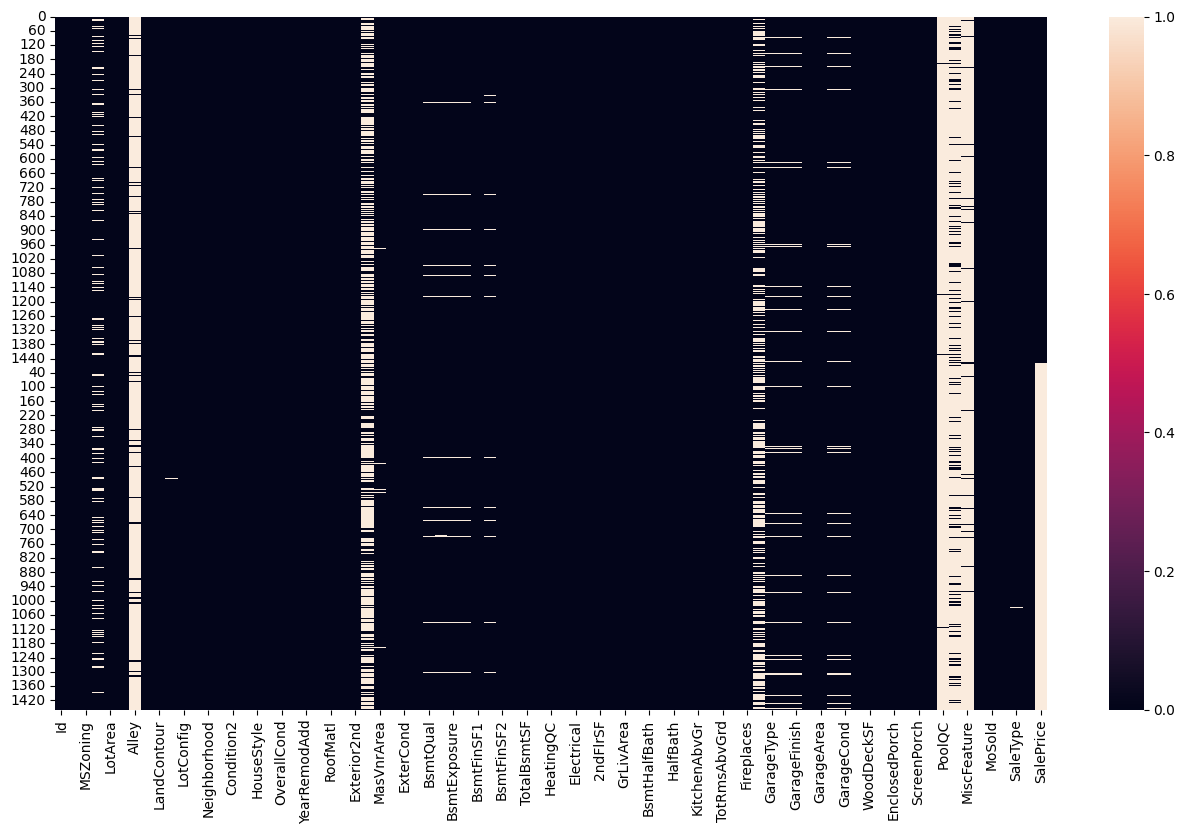

In [227]:
import os

# Configure plot figure size.
plt.figure(figsize=(16, 9))
# Provides optimal readability for the heatmap.

# Visualize missing values across the DataFrame.
sns.heatmap(df.isnull())

# Create the directory if it does not exist
output_dir = "EDA_img"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Save the generated plot to a file.
plt.savefig(f"{output_dir}/heatmap_DF_of_null_values.png")

## Calculate Missing Value Percentages

In [235]:
df.set_index("Id") # Set the 'Id' column as the DataFrame index.

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706.0,Unf,0.0,150.0,856.0,GasA,Ex,Y,SBrkr,856,854,0,1710,1.0,0.0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2.0,548.0,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500.0
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978.0,Unf,0.0,284.0,1262.0,GasA,Ex,Y,SBrkr,1262,0,0,1262,0.0,1.0,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2.0,460.0,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.0
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486.0,Unf,0.0,434.0,920.0,GasA,Ex,Y,SBrkr,920,866,0,1786,1.0,0.0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2.0,608.0,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500.0
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216.0,Unf,0.0,540.0,756.0,GasA,Gd,Y,SBrkr,961,756,0,1717,1.0,0.0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3.0,642.0,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.0
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655.0,Unf,0.0,490.0,1145.0,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1.0,0.0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3.0,836.0,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,Twnhs,2Story,4,7,1970,1970,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Unf,0.0,Unf,0.0,546.0,546.0,GasA,Gd,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,5,Typ,0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal,NaN
2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,TwnhsE,2Story,4,5,1970,1970,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,252.0,Unf,0.0,294.0,546.0,GasA,TA,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,6,Typ,0,NaN,CarPort,1970.0,Unf,1.0,286.0,TA,TA,Y,0,24,0,0,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml,NaN
2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1Story,5,7,1960,1996,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,ALQ,1224.0,Unf,0.0,0.0,1224.0,GasA,Ex,Y,SBrkr,1224,0,0,1224,1.0,0.0,1,0,4,1,TA,7,Typ,1,TA,Detchd,1960.0,Unf,2.0,576.0,TA,TA,Y,474,0,0,0,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml,NaN


In [ ]:

# Calculate missing values for all columns
null_percentage = df.isnull().sum()

# Filter and show ONLY columns that have missing values (> 0)
null_count = null_percentage[null_percentage > 0]

null_count


In [ ]:
# Tell Pandas to show ALL rows, no matter how many there are
pd.set_option('display.max_rows', None)

# Now calculate and print the percentage
null_percentage = (df.isnull().sum()/df.shape[0]*100)


null_percentage


# Drop Columns/Features
## Decision on Feature Dropping
Based on initial observations, no features will be dropped at this stage.

In [ ]:
# find the columns where missing value percentage is greater than 50%
miss_value_50_perc = null_percentage[null_percentage > 50]

miss_value_50_perc

In [250]:
# Based on domain knowledge, columns with more than 50% missing values will not be dropped.
# Instead, 'NA' (Not Applicable) will be used to fill these missing values.

# Re-calculate null_percentage to ensure it's defined
null_percentage = (df.isnull().sum()/df.shape[0]*100)

miss_value_50_perc = null_percentage[null_percentage > 50]

miss_value_50_perc

,0
Alley,93.216855
MasVnrType,60.500171
PoolQC,99.657417
Fence,80.438506
MiscFeature,96.402878


In [237]:
df["Alley"].value_counts() # Display the value counts for the 'Alley' feature.

,count
Alley,
Grvl,120
Pave,78


In [238]:
df["PoolQC"].value_counts() # Display the value counts for the 'PoolQC' feature.

,count
PoolQC,
Ex,4
Gd,4
Fa,2


In [239]:
df["Fence"].value_counts() # Display the value counts for the 'Fence' feature.

,count
Fence,
MnPrv,329
GdPrv,118
GdWo,112
MnWw,12


In [240]:
df["MiscFeature"].value_counts() # Display the value counts for the 'MiscFeature' feature.

,count
MiscFeature,
Shed,95
Gar2,5
Othr,4
TenC,1


In [251]:
# Based on domain knowledge, the 'FireplaceQu' feature will not be dropped.
# Instead, missing values will be filled with 'NA' (No Fireplace).

# Re-calculate null_percentage to ensure it's defined
null_percentage = (df.isnull().sum()/df.shape[0]*100)

miss_value_20_50_perc = null_percentage[(null_percentage > 20) & (null_percentage <= 50)]
miss_value_20_50_perc

,0
FireplaceQu,48.646797
SalePrice,49.982871


In [ ]:

miss_value_5_20_perc = null_percentage[(null_percentage > 5) & (null_percentage <= 20)]
miss_value_5_20_perc

In [242]:
df["LotFrontage"].value_counts().head() # This is an important feature as it indicates street distance; therefore, it will not be removed.

,count
LotFrontage,
60.0,276
80.0,137
70.0,133
50.0,117
75.0,105


In [ ]:
# 1. Get the names of columns that have 5% to 20% missing values
# 2. Select only those specific columns from the main dataframe 'df'
# 3. Check for missing values in these selected columns (returns True/False)
# 4. Draw a heatmap to visually see where the data is missing (Yellow = Missing, Dark =

sns.heatmap(df[miss_value_5_20_perc.keys()].isnull())

## Mising Value Imputation:

 - Missing Value Imputation means filling in the empty (missing/NaN) values that exist in the data..
 - Machine Learning models can't understand empty data (NaN) and throw an error,
 - which is why we replace these missing values with some logical value.

# Imputation Strategies: Practical Guidelines

For most real-world scenarios, straightforward imputation methods suffice:

1.  **Mean**: Suitable for numerical data without significant outliers (e.g., normal distribution).
2.  **Median**: Robust for numerical data containing outliers.

### Categorical Data:

1.  **Mode**: Used for categorical data to replace missing values with the most frequent category.

### Critical Principle: Prevent Data Leakage

1.  Fit imputer exclusively on training data.
2.  Transform both training and test data using the fitted imputer.

This methodology prevents data leakage from the test set into the training process.

In [ ]:
# get the total_missing value feature

missing_value_feat = null_percentage[null_percentage > 0]

print(f"Total missing value features: {len(missing_value_feat)}")

In [ ]:
missing_value_feat

In [ ]:
# find text columns with missing data to apply mode imputation later
cat_na_feat = missing_value_feat[missing_value_feat.keys().isin(object_feature)]

print(f"Total number of categorical missing features: {len(cat_na_feat)} ")

cat_na_feat

In [ ]:
# filter integer columns that have missing values
int_na_feat = missing_value_feat[missing_value_feat.keys().isin(int_feature)]

print(f"Total number of integer missing features: {len(int_na_feat)} ")

int_na_feat

In [ ]:

# filter float columns that have missing values
float_na_feat = missing_value_feat[missing_value_feat.keys().isin(float_feature)]

print(f"Total number of float missing features: {len(float_na_feat)} ")

float_na_feat

### Handling Missing Values in 'MSZoning'

In [243]:
df["MSZoning"].value_counts() # Display the value counts for the 'MSZoning' feature.

,count
MSZoning,
RL,2265
RM,460
FV,139
RH,26
C (all),25


<Axes: xlabel='count', ylabel='MSZoning'>

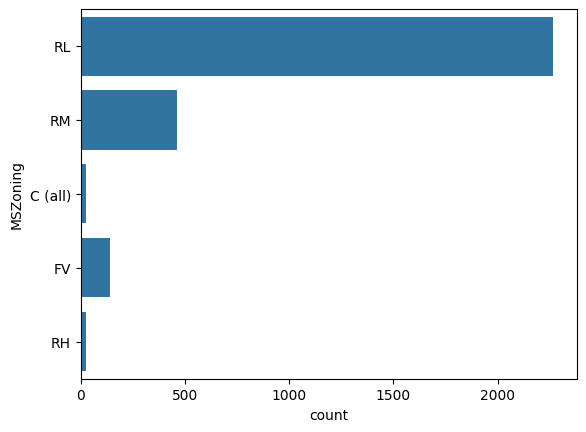

In [244]:
sns.countplot(df["MSZoning"]) # Visualize the distribution of 'MSZoning' categories.

### Backup of original data

In [ ]:
df_mvi = df.copy()
df_mvi.shape

In [ ]:

# find the most frequent value in the column
mszoning_mode = df["MSZoning"].mode()[0]

# replace NaN safely without using inplace=True
df_mvi["MSZoning"] = df_mvi["MSZoning"].replace(np.nan, mszoning_mode)

# verify that no missing values are left (should output 0)
df_mvi["MSZoning"].isnull().sum()

In [252]:
# plot horizontal count of each category in MSZoning for better readability
sns.countplot(data=df_mvi, y="MSZoning")
plt.title("MSZoning Distribution After Imputation") # Add title for clarity
plt.show()

KeyError: 'MSZoning'

In [ ]:
def oldNewCountPlot(df, df_new, feature):
    # reset index inside function to prevent duplicate label errors
    df = df.reset_index(drop=True)
    df_new = df_new.reset_index(drop=True)

    # create left subplot for original data
    plt.subplot(121)
    sns.countplot(x=feature, data=df)
    plt.title("Old Data Distribution")

    # create right subplot for new data
    plt.subplot(122)
    sns.countplot(x=feature, data=df_new)
    plt.title("New Data Distribution")

    # display both plots side by side
    plt.show()

# call the function
oldNewCountPlot(df, df_mvi, "MSZoning")

### Handling Missing Values in 'Alley'

ValueError: Could not interpret value `Alley` for `x`. An entry with this name does not appear in `data`.

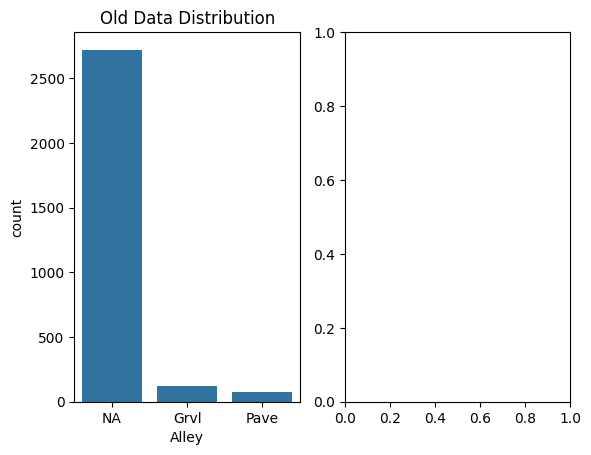

In [253]:
# Visualize the old and new distributions for 'Alley'
oldNewCountPlot(df, df_mvi, "Alley")

In [ ]:

# fill missing values with "NA" (no alley access)
alley_constant = "NA"

# fill missing values in the "Alley" column with the defined constant
df_mvi["Alley"] = df_mvi["Alley"].fillna(alley_constant)

# verify and display result

missing_count = df_mvi["Alley"].isnull().sum()
print(f"Missing Values: {missing_count}")
print("\nUpdated distribution:")
print(df_mvi["Alley"].value_counts())


In [ ]:
# visualize the updated Alley distribution
sns.countplot(x="Alley", data=df_mvi)
plt.title("Alley Distribution After Imputation")
plt.show()

In [254]:
def oldNewCountPlot(df, df_new, feature):
    """
    Compare distribution of a new feature before and after imputation.
    Creates side-by-side horizontal countplots for visual verification.
    """

    # Use a copy to avoid modifying original df and reset index for robust plotting.
    df_plot = df.copy()
    df_new_plot = df_new.copy()

    # For categorical features that get 'NA' imputation, fill original NaNs for plotting consistency
    if feature in ["Alley", "FireplaceQu", "PoolQC", "Fence", "MiscFeature", "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2", "GarageType", "GarageFinish", "GarageQual", "GarageCond"]:
        df_plot[feature] = df_plot[feature].fillna("NA")

    # Create left subplot for original data.
    plt.subplot(121)

    # Plot original data distribution as a horizontal countplot.
    sns.countplot(y=df_plot[feature])
    plt.title("Original Data Distribution")

    # Create right subplot for imputed data.
    plt.subplot(122)

    # Plot imputed data distribution as a horizontal countplot.
    sns.countplot(y=df_new_plot[feature])
    plt.title("Imputed Data Distribution")

    # Display plots.
    plt.tight_layout()
    plt.show()

In [ ]:
print("Data Type of LotFrontage")
print(df["LotFrontage"].dtype)

print(df["LotFrontage"].head())

## Handling Lotfrontage

## 'LotFrontage' Feature Overview

In [ ]:
# define function to visualize numerical data distribution
# take data-frame (or series) and optional figure size as input
def boxHisplot(df, figsize=(16, 5)):
    """
    Create side-by-side boxplot & histogram for numerical data analysis.
    Helps decide whether to use mean or median for numerical data.
    """

    # reset the index to remove duplicate labels (this fixes the seaborn error!)
    df = df.reset_index(drop=True)

    # create a figure with specified size (default 16x5 inches)
    plt.figure(figsize=figsize)

    # create left subplot for boxplot (1 row, 2 columns, position 1)
    plt.subplot(1, 2, 1)

    # draw VERTICAL boxplot using x= parameter
    # x= makes the boxplot stand upright instead of lying down
    sns.boxplot(x=df)

    # add a title to identify the plot
    plt.title("Boxplot - Check for Outliers")

    # create right subplot for histogram (1 row, 2 columns, position 2)
    plt.subplot(1, 2, 2)

    # draw histogram to see data distribution shape
    # histogram shows frequency of values in bins, kde adds a smooth curve
    sns.histplot(data=df, bins=30, kde=True)

    # add a title to identify the plot
    plt.title("Histogram - Check for Skewness")

    # adjust layout so titles and labels don't overlap
    plt.tight_layout()

    # display the plots on the screen
    plt.show()

# analyze LotFrontage column to decide mean or median
boxHisplot(df["LotFrontage"])

In [ ]:
lot_frontage_mean = df["LotFrontage"].mean()
lot_frontage_mean

In [ ]:
# step 1: calculate the mean from the original dataframe (prevents data leakage)
lot_frontage_mean = df["LotFrontage"].mean()

# step 2: fill missing values in df_mvi safely using direct assignment
# (avoiding inplace=True to prevent Pandas 2.0 errors)
df_mvi["LotFrontage"] = df_mvi["LotFrontage"].fillna(lot_frontage_mean)

# step 3: verify that no missing values are left in the column
print("Missing values after imputation:", df_mvi["LotFrontage"].isnull().sum())

In [ ]:
# recreate df_mvi as a full DataFrame copy to fix the Series error
df_mvi = df.copy()

# now check if the column exists (this will work perfectly now)
print("LotFrontage in df_mvi:", "LotFrontage" in df_mvi.columns)

In [119]:
# create a copy of orginial data_frmae

df_mvi = df.copy()

# confirm is the shape is same or not

print(df_mvi.shape)

(2919, 81)


## MSZoning Mode Imputation


In [120]:
msznoning_mode = df["MSZoning"].mode()[0]
print(f"MSZonining mode: {msznoning_mode}")

# Fill the missing values to mode
df_mvi["MSZoning"] = df_mvi["MSZoning"].replace(np.nan, msznoning_mode)

# verification
print(f"MSZoning missing after imputation: {df_mvi['MSZoning'].isnull().sum()}")

MSZonining mode: RL
MSZoning missing after imputation: 0


## Alley missing values mean "No access"

In [121]:
df_mvi["Alley"] = df_mvi["Alley"].fillna("NA")

# After verification
print(f"Alley missing after imputation: {df_mvi['Alley'].isnull().sum()}")
print("\nAlley Counts: ")
print(df_mvi["Alley"].value_counts())

Alley missing after imputation: 0

Alley Counts: 
Alley
NA      2721
Grvl     120
Pave      78
Name: count, dtype: int64


# Calculate Mean of LotFrontage

In [122]:
# calculate the mean of lot frontage

lot_frontage_mean = df["LotFrontage"].mean()
print(f"LotFrontage mean: {lot_frontage_mean}")

# Fill the missing values with the mean
df_mvi["LotFrontage"] = df_mvi["LotFrontage"].replace(np.nan, lot_frontage_mean)

# verification after imputation
print(f"LotFrontage missing after imputation: {df_mvi['LotFrontage'].isnull().sum()}")

LotFrontage mean: 69.30579531442663
LotFrontage missing after imputation: 0


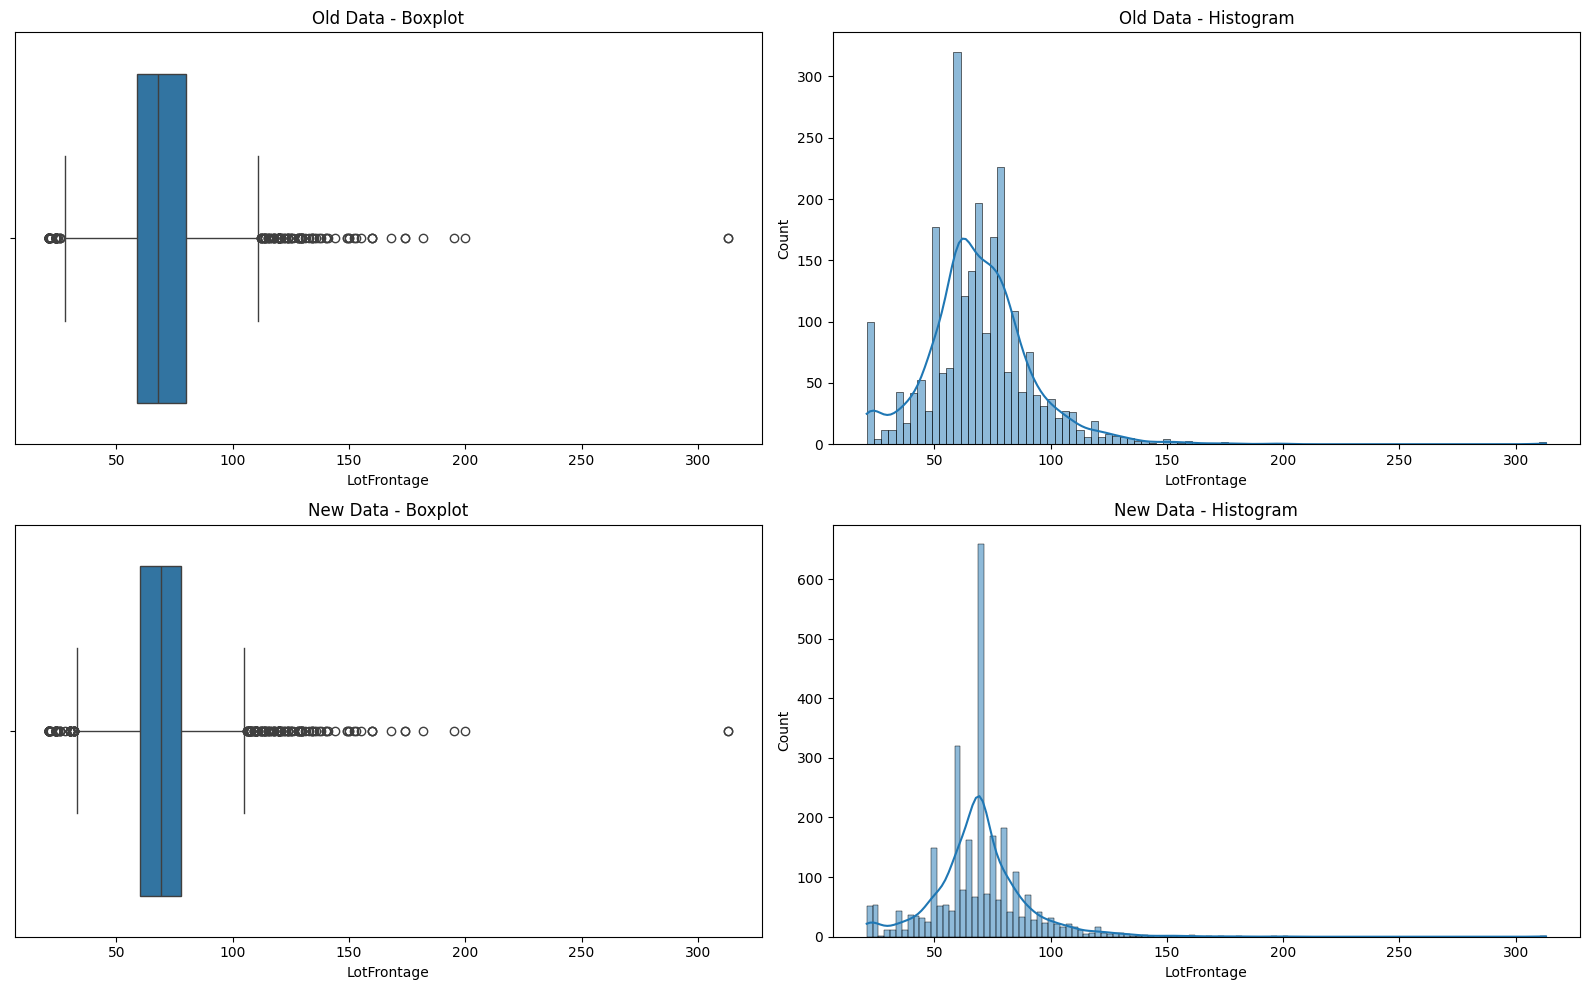

In [123]:
# Define a function to compare old and new distributions for a numerical feature
def oldNewBoxHistPlot(df, df_new, feature, figsize=(16, 10)):
    """
    Compare old and new distributions of a numerical feature.
    Creates 4 plots: old boxplot, old histogram, new boxplot, new histogram.
    """

    # Reset the index of the old dataframe to avoid duplicate label errors
    df = df.reset_index(drop=True)

    # Reset the index of the new dataframe to avoid duplicate label errors
    df_new = df_new.reset_index(drop=True)

    # Create a blank canvas with the given figure size
    plt.figure(figsize=figsize)

    # --- Plot 1: Old Data Boxplot (top-left position) ---
    # Create the first subplot in a 2x2 grid at position 1
    plt.subplot(2, 2, 1)
    # Draw a boxplot for the old data to see outliers and spread
    sns.boxplot(x=df[feature])
    # Add a title to the first plot
    plt.title("Old Data - Boxplot")

    # --- Plot 2: Old Data Histogram (top-right position) ---
    # Create the second subplot in a 2x2 grid at position 2
    plt.subplot(2, 2, 2)
    # Draw a histogram with a smooth curve (KDE) to see the distribution shape
    sns.histplot(df[feature], kde=True)
    # Add a title to the second plot
    plt.title("Old Data - Histogram")

    # --- Plot 3: New Data Boxplot (bottom-left position) ---
    # Create the third subplot in a 2x2 grid at position 3
    plt.subplot(2, 2, 3)
    # Draw a boxplot for the new data to see outliers and spread after imputation
    sns.boxplot(x=df_new[feature])
    # Add a title to the third plot
    plt.title("New Data - Boxplot")

    # --- Plot 4: New Data Histogram (bottom-right position) ---
    # Create the fourth subplot in a 2x2 grid at position 4
    plt.subplot(2, 2, 4)
    # Draw a histogram with a smooth curve (KDE) for the new data
    sns.histplot(df_new[feature], kde=True)
    # Add a title to the fourth plot
    plt.title("New Data - Histogram")

    # Adjust the spacing between plots so they do not overlap
    plt.tight_layout()

    # Display all four plots on the screen
    plt.show()

 # Call the function to compare old and new distributions of LotFrontage
oldNewBoxHistPlot(df, df_mvi, "LotFrontage")

### Handling Missing Values in 'Utilities'

In [124]:
# show the count of each category in the 'Utilities' column
df['Utilities'].value_counts()

,count
Utilities,
AllPub,2916
NoSeWa,1


In [125]:
# Find the most frequent values in the 'Utilities' column
utilities_Mode = df['Utilities'].mode()[0]

# Fill missing values in df_mvi with the mode value
df_mvi['Utilities'] = df_mvi['Utilities'].replace(np.nan,utilities_Mode)


# Verify that no missing values are left
df_mvi['Utilities'].isnull().sum()

np.int64(0)

### Handling Missing Values in 'Exterior1st' and 'Exterior2nd'

In [126]:
df["Exterior1st"].value_counts()

,count
Exterior1st,
VinylSd,1025
MetalSd,450
HdBoard,442
Wd Sdng,411
Plywood,221
CemntBd,126
BrkFace,87
WdShing,56
AsbShng,44


In [127]:
df["Exterior2nd"].value_counts()

,count
Exterior2nd,
VinylSd,1014
MetalSd,447
HdBoard,406
Wd Sdng,391
Plywood,270
CmentBd,126
Wd Shng,81
BrkFace,47
Stucco,47


In [128]:
# Find the most frequent value in the Exterior1st column
exterior1st_mode = df["Exterior1st"].mode()[0]


# Find the most frequent value in the Exterior2nd column
exterior2nd_mode = df["Exterior2nd"].mode()[0]

# Fill missing values in Exterior1st with its mode value
df_mvi["Exterior1st"] = df_mvi["Exterior1st"].replace(np.nan, exterior1st_mode)

# Fill missing values in Exterior2nd with its mode value
df_mvi["Exterior2nd"] = df_mvi["Exterior2nd"].replace(np.nan, exterior2nd_mode)

# Verify that no missing values are left in Exterior1st
print("Exterior1st null count:", df_mvi["Exterior1st"].isnull().sum())

print("Exterior2nd null count:", df_mvi["Exterior2nd"].isnull().sum())

Exterior1st null count: 0
Exterior2nd null count: 0


### Handling Missing Values in 'MasVnrType' and 'MasVnrArea'

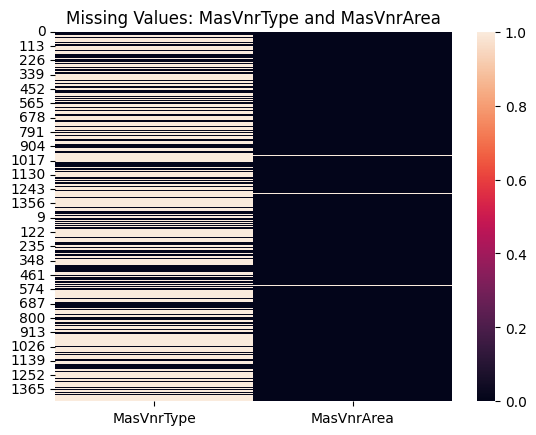

In [129]:
#create a heatmap to visualize missing values in both columns

sns.heatmap(df[["MasVnrType", "MasVnrArea"]].isnull())

plt.title("Missing Values: MasVnrType and MasVnrArea")
plt.show()

In [130]:
df[df[["MasVnrType", "MasVnrArea"]].isnull().any(axis=1)]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978.0,Unf,0.0,284.0,1262.0,GasA,Ex,Y,SBrkr,1262,0,0,1262,0.0,1.0,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2.0,460.0,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500.0
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216.0,Unf,0.0,540.0,756.0,GasA,Gd,Y,SBrkr,961,756,0,1717,1.0,0.0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3.0,642.0,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000.0
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1.5Fin,5,5,1993,1995,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,Wood,Gd,TA,No,GLQ,732.0,Unf,0.0,64.0,796.0,GasA,Ex,Y,SBrkr,796,566,0,1362,1.0,0.0,1,1,1,1,TA,5,Typ,0,NaN,Attchd,1993.0,Unf,2.0,480.0,TA,TA,Y,40,30,0,320,0,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000.0
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,OldTown,Artery,Norm,1Fam,1.5Fin,7,5,1931,1950,Gable,CompShg,BrkFace,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,TA,No,Unf,0.0,Unf,0.0,952.0,952.0,GasA,Gd,Y,FuseF,1022,752,0,1774,0.0,0.0,2,0,2,2,TA,8,Min1,2,TA,Detchd,1931.0,Unf,2.0,468.0,Fa,TA,Y,90,0,205,0,0,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900.0
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,BrkSide,Artery,Artery,2fmCon,1.5Unf,5,6,1939,1950,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,BrkTil,TA,TA,No,GLQ,851.0,Unf,0.0,140.0,991.0,GasA,Ex,Y,SBrkr,1077,0,0,1077,1.0,0.0,1,0,2,2,TA,5,Typ,2,TA,Attchd,1939.0,RFn,1.0,205.0,Gd,TA,Y,0,4,0,0,0,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1453,2914,160,RM,21.0,1526,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,Twnhs,2Story,4,5,1970,1970,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Unf,0.0,Unf,0.0,546.0,546.0,GasA,TA,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,5,Typ,0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,Y,0,34,0,0,0,0,NaN,GdPrv,NaN,0,6,2006,WD,Normal,NaN
1454,2915,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,Twnhs,2Story,4,7,1970,1970,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Unf,0.0,Unf,0.0,546.0,546.0,GasA,Gd,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,5,Typ,0,NaN,NaN,NaN,NaN,0.0,0.0,NaN,NaN,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal,NaN
1455,2916,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,MeadowV,Norm,Norm,TwnhsE,2Story,4,5,1970,1970,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,252.0,Unf,0.0,294.0,546.0,GasA,TA,Y,SBrkr,546,546,0,1092,0.0,0.0,1,1,3,1,TA,6,Typ,0,NaN,CarPort,1970.0,Unf,1.0,286.0,TA,TA,Y,0,24,0,0,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml,NaN
1456,2917,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1F

In [131]:
df["MasVnrType"].value_counts()

,count
MasVnrType,
BrkFace,879
Stone,249
BrkCmn,25


In [132]:
# Find the most frequent value in the MasVnrType column
mass_vnr_type_mode = df["MasVnrType"].mode()[0]

# Print the mode value to check it
print(f"MasVnrType mode: {mass_vnr_type_mode}")


# Fill the missing values in the MasVnrType column with the mode value
df_mvi["MasVnrType"] = df_mvi["MasVnrType"].replace(np.nan, mass_vnr_type_mode)

# Verify that no missing values are left
print(f"MasVnrType missing values after imputation: {df_mvi['MasVnrType'].isnull().sum()}")

MasVnrType mode: BrkFace
MasVnrType missing values after imputation: 0


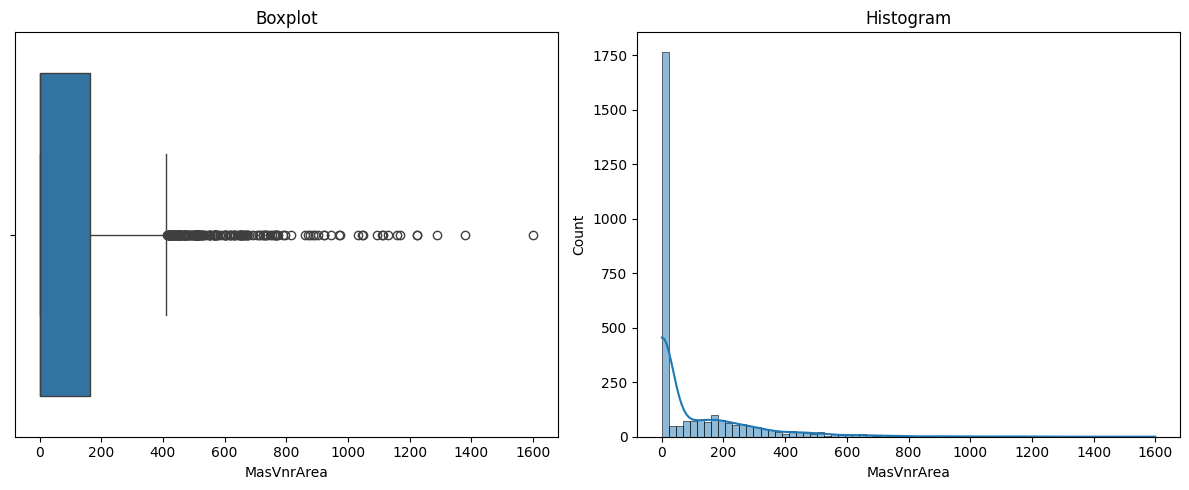

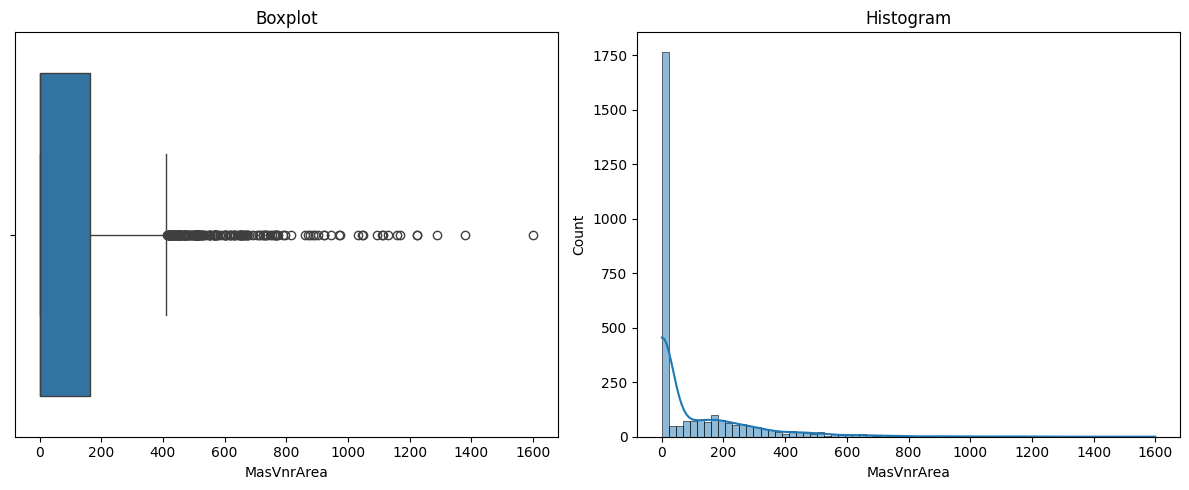

In [133]:
# Define a function to show boxplot and histogram for a single feature
def boxHistPlot(series, figsize=(12, 5)):
    """
    Show boxplot and histogram for a single numerical feature.
    """

    # Reset the index of the series to avoid duplicate label errors
    series = series.reset_index(drop=True)

    # Create a blank canvas with the given figure size
    plt.figure(figsize=figsize)

    # --- Plot 1: Boxplot (left side) ---
    # Create the first subplot in a 1x2 grid at position 1
    plt.subplot(1, 2, 1)
    # Draw a boxplot to see outliers and spread
    sns.boxplot(x=series)
    # Add a title
    plt.title("Boxplot")

    # --- Plot 2: Histogram (right side) ---
    # Create the second subplot in a 1x2 grid at position 2
    plt.subplot(1, 2, 2)
    # Draw a histogram with a smooth curve (KDE)
    sns.histplot(series, kde=True)
    # Add a title
    plt.title("Histogram")

    # Adjust spacing so plots do not overlap
    plt.tight_layout()

    # Display both plots
    plt.show()


boxHistPlot(df["MasVnrArea"])
boxHistPlot(df_mvi["MasVnrArea"])

In [134]:
# Set the mode value for MasVnrArea as 0

masvnrmode_area = 0

# Fill missing values in df_mvi with the mode value (0)
df_mvi["MasVnrArea"] = df_mvi["MasVnrArea"].replace(np.nan, masvnrmode_area)

# Verify that no missing values are left
print("MasVnrArea missing after imputation:", df_mvi["MasVnrArea"].isnull().sum())

MasVnrArea missing after imputation: 0


### Handling Missing Values in Basement Features

In [135]:
# Create a list of Categorical basement features
cat_bsmt_feat = [
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",

]

# print the list to verify
print("Categorical basement features:")
print(cat_bsmt_feat)

Categorical basement features:
['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']


In [136]:
# Create a list of Numerical basement features
num_bsmt_feat = [
    "BsmtFinSF1",
    "BsmtFinSF2",
    "BsmtUnfSF",
    "TotalBsmtSF",
    "BsmtFullBath",
    "BsmtHalfBath"
]

# print the list to verify
print("Numerical basement features:")
print(num_bsmt_feat)

Numerical basement features:
['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath']


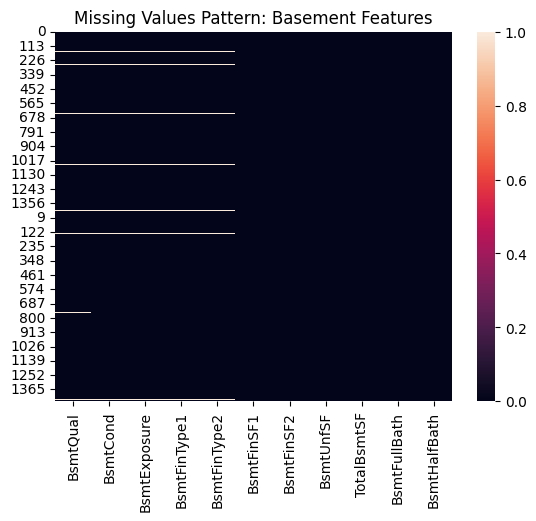

In [137]:
# Understand the Pattern via heatmap
sns.heatmap(df[cat_bsmt_feat + num_bsmt_feat].isnull())
plt.title("Missing Values Pattern: Basement Features")
plt.show()

In [138]:
# Loop through each categorical basement feature
for feature in cat_bsmt_feat:
    print(f"value count of {feature}: {df[feature].value_counts()}")


value count of BsmtQual: BsmtQual
TA    1283
Gd    1209
Ex     258
Fa      88
Name: count, dtype: int64
value count of BsmtCond: BsmtCond
TA    2606
Gd     122
Fa     104
Po       5
Name: count, dtype: int64
value count of BsmtExposure: BsmtExposure
No    1904
Av     418
Gd     276
Mn     239
Name: count, dtype: int64
value count of BsmtFinType1: BsmtFinType1
Unf    851
GLQ    849
ALQ    429
Rec    288
BLQ    269
LwQ    154
Name: count, dtype: int64
value count of BsmtFinType2: BsmtFinType2
Unf    2493
Rec     105
LwQ      87
BLQ      68
ALQ      52
GLQ      34
Name: count, dtype: int64


In [139]:
# Loop through each categorical basement feature
for feature in cat_bsmt_feat:
    # Fill the missing value with "NA" (No Basement)
    df_mvi[feature] = df_mvi[feature].fillna("NA")

    # Print the feature name and missing count after imputation
    print(f"{feature} missing after imputation : {df_mvi[feature].isnull().sum()}")

BsmtQual missing after imputation : 0
BsmtCond missing after imputation : 0
BsmtExposure missing after imputation : 0
BsmtFinType1 missing after imputation : 0
BsmtFinType2 missing after imputation : 0


In [140]:
df_bsmt = df[cat_bsmt_feat + num_bsmt_feat]
df_bsmt[df_bsmt.isnull().any(axis=1)]

,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,BsmtFullBath,BsmtHalfBath
17,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
39,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
90,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
102,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
156,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
1343,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
1344,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
1364,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0
1431,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0


In [141]:
# Loop through each numerical basement feature
for feature in num_bsmt_feat:
    #Fill missing values with 0 (No Basement)
    df_mvi[feature] = df_mvi[feature].fillna(0)

    #print the feature name and missing count after imputation
    print(f"{feature} missing count after imputation: {df_mvi[feature].isnull().sum()}")

BsmtFinSF1 missing count after imputation: 0
BsmtFinSF2 missing count after imputation: 0
BsmtUnfSF missing count after imputation: 0
TotalBsmtSF missing count after imputation: 0
BsmtFullBath missing count after imputation: 0
BsmtHalfBath missing count after imputation: 0


### Handling Missing Values in 'Electrical' and 'KitchenQual'

In [142]:
df["Electrical"].value_counts()

,count
Electrical,
SBrkr,2671
FuseA,188
FuseF,50
FuseP,8
Mix,1


In [143]:
df["KitchenQual"].value_counts()

,count
KitchenQual,
TA,1492
Gd,1151
Ex,205
Fa,70


In [144]:
# Show rows where Electrical, KitchenQual, or KitchenAbvGr is missing
df_ekk = df[[ "Electrical", "KitchenQual", "KitchenAbvGr"]]
df_ekk[df_ekk.isnull().any(axis=1)]


,Electrical,KitchenQual,KitchenAbvGr
1379,NaN,Gd,1
95,SBrkr,NaN,1


In [145]:
# Find the most frequent value in the Electrical column
electrical_mode = df["Electrical"].mode()[0]


# Fill missing values in the df_mvi with the mode value
df_mvi["Electrical"] = df_mvi["Electrical"].fillna(electrical_mode)


# Verify that no missing values are left
print("Electrical missing after imputation: ", df_mvi["Electrical"].isnull().sum())

Electrical missing after imputation:  0


### Handling Remaining Categorical Features

In [146]:
df["Functional"].value_counts()

,count
Functional,
Typ,2717
Min2,70
Min1,65
Mod,35
Maj1,19
Maj2,9
Sev,2


In [147]:
df["SaleType"].value_counts()

,count
SaleType,
WD,2525
New,239
COD,87
ConLD,26
CWD,12
ConLI,9
ConLw,8
Oth,7
Con,5


In [148]:
# Find the most frequent value in the Functional column

functional_mode = df["Functional"].mode()[0]

# Print the mode value to check it
print(f"Functional Mode: {functional_mode}")


# Fill missing values in df_mvi with the mode value
df_mvi["Functional"] = df_mvi["Functional"].replace(np.nan, functional_mode)

# Verify that no missing values are left
print("Functional missing after imputation: ", df_mvi["Functional"].isnull().sum())

Functional Mode: Typ
Functional missing after imputation:  0


In [149]:
# Find the most frequent value in the SaleType column

saletype_mode = df["SaleType"].mode()[0]

# Print the mode value to check it
print(f"SaleType Mode: {saletype_mode}")

# Fill missing values in df_mvi with the mode value
df_mvi["SaleType"] = df_mvi["SaleType"].replace(np.nan, saletype_mode)

# Verify that no missing values are left
print("SaleType missing after imputation:", df_mvi["SaleType"].isnull().sum())

SaleType Mode: WD
SaleType missing after imputation: 0


In [150]:
# Create a list of other categorical features with high missing values

other_cat_feat = ["FireplaceQu", "PoolQC", "Fence", "MiscFeature"]

# Loop through each feature and print its value counts
for feat in other_cat_feat:
    print(f"Value count of {feat}:")
    print(df[feat].value_counts())
    print("-" * 40)

Value count of FireplaceQu:
FireplaceQu
Gd    744
TA    592
Fa     74
Po     46
Ex     43
Name: count, dtype: int64
----------------------------------------
Value count of PoolQC:
PoolQC
Ex    4
Gd    4
Fa    2
Name: count, dtype: int64
----------------------------------------
Value count of Fence:
Fence
MnPrv    329
GdPrv    118
GdWo     112
MnWw      12
Name: count, dtype: int64
----------------------------------------
Value count of MiscFeature:
MiscFeature
Shed    95
Gar2     5
Othr     4
TenC     1
Name: count, dtype: int64
----------------------------------------


In [151]:
# Fill missing values in FireplaceQu with "NA" (No Fireplace)
df_mvi["FireplaceQu"] = df_mvi["FireplaceQu"].fillna("NA")
print("FireplaceQu missing after imputation:", df_mvi["FireplaceQu"].isnull().sum())

# Fill missing values in PoolQC with "NA" (No Pool)
df_mvi["PoolQC"] = df_mvi["PoolQC"].fillna("NA")
print("PoolQC missing after imputation:", df_mvi["PoolQC"].isnull().sum())

# Fill missing values in Fence with "NA" (No Fence)
df_mvi["Fence"] = df_mvi["Fence"].fillna("NA")
print("Fence missing after imputation:", df_mvi["Fence"].isnull().sum())

# Fill missing values in MiscFeature with "NA" (None)
df_mvi["MiscFeature"] = df_mvi["MiscFeature"].fillna("NA")
print("MiscFeature missing after imputation:", df_mvi["MiscFeature"].isnull().sum())

FireplaceQu missing after imputation: 0
PoolQC missing after imputation: 0
Fence missing after imputation: 0
MiscFeature missing after imputation: 0


In [229]:
# Verify remaining missing values in KitchenQual.
print("KitchenQual missing:", df_mvi["KitchenQual"].isnull().sum())

KitchenQual missing: 0


In [153]:
df["KitchenQual"].value_counts()

,count
KitchenQual,
TA,1492
Gd,1151
Ex,205
Fa,70


In [154]:
kitchenqual_mode = df["KitchenQual"].mode()[0]

print(f"KitchenQual Mode: {kitchenqual_mode}")

df_mvi["KitchenQual"] = df_mvi["KitchenQual"].fillna(kitchenqual_mode)

print("KitchenQual missing after imputation:", df_mvi["KitchenQual"].isnull().sum())

KitchenQual Mode: TA
KitchenQual missing after imputation: 0


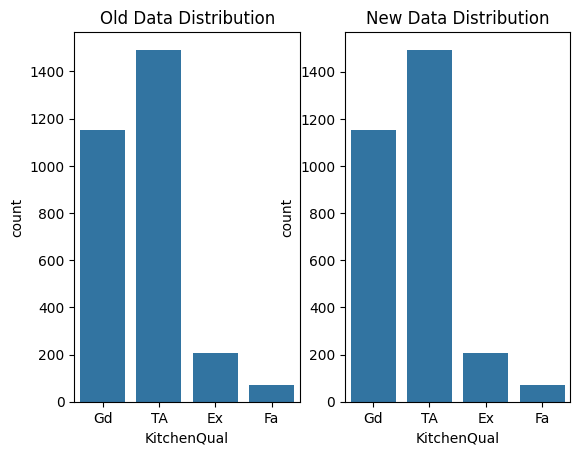

In [155]:
oldNewCountPlot(df, df_mvi, "KitchenQual")

### Handling Garage Type

In [156]:
# Create a list of categorical garage features
cat_garage_feat = ['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']

# Create a list of numerical garage features
num_garage_feat = ['GarageYrBlt', 'GarageCars', 'GarageArea']

# Print the lists to verify
print("Categorical Garage Features:", cat_garage_feat)
print("Numerical Garage Features:", num_garage_feat)

Categorical Garage Features: ['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']
Numerical Garage Features: ['GarageYrBlt', 'GarageCars', 'GarageArea']


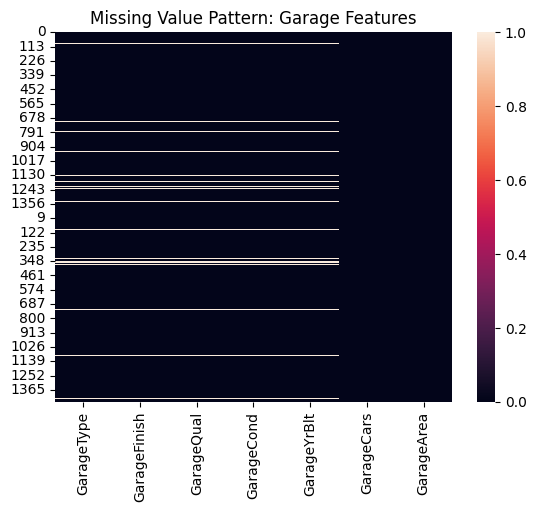

In [157]:
# Create a heatmap to see missing value patterns in garage features

sns.heatmap(df[cat_garage_feat + num_garage_feat].isnull())
plt.title("Missing Value Pattern: Garage Features")
plt.show()

In [158]:
# Create a new dataframe with only garage features
df_garage = df[cat_garage_feat + num_garage_feat]

# Show only rows where any garage feature is missing
df_garage[df_garage.isnull().any(axis=1)]

,GarageType,GarageFinish,GarageQual,GarageCond,GarageYrBlt,GarageCars,GarageArea
39,NaN,NaN,NaN,NaN,NaN,0.0,0.0
48,NaN,NaN,NaN,NaN,NaN,0.0,0.0
78,NaN,NaN,NaN,NaN,NaN,0.0,0.0
88,NaN,NaN,NaN,NaN,NaN,0.0,0.0
89,NaN,NaN,NaN,NaN,NaN,0.0,0.0
...,...,...,...,...,...,...,...
1433,NaN,NaN,NaN,NaN,NaN,0.0,0.0
1449,NaN,NaN,NaN,NaN,NaN,0.0,0.0
1453,NaN,NaN,NaN,NaN,NaN,0.0,0.0
1454,NaN,NaN,NaN,NaN,NaN,0.0,0.0


In [159]:
# Loop through each categorical garage feature

for feature in cat_garage_feat:
    # Fill the missing values with "NA" (No Garage)
    df_mvi[feature] = df[feature].fillna("NA")

    # Print the feature name and missing count after imputation
    print(f"{feature} missing after imputation: {df_mvi[feature].isnull().sum()}")

GarageType missing after imputation: 0
GarageFinish missing after imputation: 0
GarageQual missing after imputation: 0
GarageCond missing after imputation: 0


In [160]:
# Loop through each numerical garage feature
for feature in num_garage_feat:
    # Fill missing values with 0 (No Garage)
    df_mvi[feature] = df_mvi[feature].fillna(0)

    # Print the feature name and missing count after imputation
    print(f"{feature} missing after imputation: {df_mvi[feature].isnull().sum()}")

GarageYrBlt missing after imputation: 0
GarageCars missing after imputation: 0
GarageArea missing after imputation: 0


In [161]:
# Check how many rows still have any missing value
df_mvi.isnull().any(axis=1).sum()

np.int64(1459)

### Feature Transformation
#### Converting Numerical Features to Categorical Features

In [162]:
for_num_conv = ["MSSubClass", "YearBuilt", "YearRemodAdd", "GarageYrBlt", "MoSold", "YrSold"]
for feat in for_num_conv:
    print(f"{feat}: data type = {df_mvi[feat].dtype}")

MSSubClass: data type = int64
YearBuilt: data type = int64
YearRemodAdd: data type = int64
GarageYrBlt: data type = float64
MoSold: data type = int64
YrSold: data type = int64


In [163]:
df_mvi[for_num_conv].head()

,MSSubClass,YearBuilt,YearRemodAdd,GarageYrBlt,MoSold,YrSold
0,60,2003,2003,2003.0,2,2008
1,20,1976,1976,1976.0,5,2007
2,60,2001,2002,2001.0,9,2008
3,70,1915,1970,1998.0,2,2006
4,60,2000,2000,2000.0,12,2008


In [164]:
# checking unique values

df_mvi["MoSold"].unique()

array([ 2,  5,  9, 12, 10,  8, 11,  4,  1,  7,  3,  6])

In [165]:
calendar.month_abbr[12]

'Dec'

In [166]:
df_mvi["MoSold"]= df_mvi["MoSold"].apply(lambda x: calendar.month_abbr[x])
df_mvi["MoSold"].unique()

array(['Feb', 'May', 'Sep', 'Dec', 'Oct', 'Aug', 'Nov', 'Apr', 'Jan',
       'Jul', 'Mar', 'Jun'], dtype=object)

In [167]:
for feat in for_num_conv:
    df_mvi[feat] = df_mvi[feat].astype(str)

In [168]:
for_num_conv = ["MSSubClass", "YearBuilt", "YearRemodAdd", "GarageYrBlt", "MoSold", "YrSold"]
for feat in for_num_conv:
    print(f"{feat}: data type = {df_mvi[feat].dtype}")

MSSubClass: data type = object
YearBuilt: data type = object
YearRemodAdd: data type = object
GarageYrBlt: data type = object
MoSold: data type = object
YrSold: data type = object


### Ordinal Encoding

In [169]:
ordinal_enc_var = [
    "ExterQual",
    "ExterCond",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "HeatingQC",
    "KitchenQual",
    "FireplaceQu",
    "GarageQual",
    "GarageCond",
    "PoolQC",
    "Functional",
    "GarageFinish",
    "PavedDrive",
    "Utilities"
]

print("Total number of features to convert ordinal numerical format:", len(ordinal_enc_var))

Total number of features to convert ordinal numerical format: 17


In [170]:
# Assign the result back to the column
df_mvi["ExterQual"] = df_mvi["ExterQual"].astype(
    CategoricalDtype(categories=["Po", "Fa", "TA", "Gd", "Ex"], ordered=True)
)

# Now check the data type
print(df_mvi["ExterQual"].dtype)

category


In [171]:
# Create a dictionary with each feature and its category order
ordinal_categories = {
    "ExterQual": ["Po", "Fa", "TA", "Gd", "Ex"],
    "ExterCond": ["Po", "Fa", "TA", "Gd", "Ex"],
    "BsmtQual": ["NA", "Po", "Fa", "TA", "Gd", "Ex"],
    "BsmtCond": ["NA", "Po", "Fa", "TA", "Gd", "Ex"],
    "BsmtExposure": ["NA", "No", "Mn", "Av", "Gd"],
    "BsmtFinType1": ["NA", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    "BsmtFinType2": ["NA", "Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    "HeatingQC": ["Po", "Fa", "TA", "Gd", "Ex"],
    "KitchenQual": ["Po", "Fa", "TA", "Gd", "Ex"],
    "FireplaceQu": ["NA", "Po", "Fa", "TA", "Gd", "Ex"],
    "GarageQual": ["NA", "Po", "Fa", "TA", "Gd", "Ex"],
    "GarageCond": ["NA", "Po", "Fa", "TA", "Gd", "Ex"],
    "PoolQC": ["NA", "Fa", "TA", "Gd", "Ex"],
    "Functional": ["Sal", "Sev", "Maj2", "Maj1", "Mod", "Min2", "Min1", "Typ"],
    "GarageFinish": ["NA", "Unf", "RFn", "Fin"],
    "PavedDrive": ["N", "P", "Y"],
    "Utilities": ["ELO", "NoSeWa", "NoSewr", "AllPub"]
}

# Loop through each feature and convert to ordered categorical
for feature, categories in ordinal_categories.items():
    df_mvi[feature] = df_mvi[feature].astype(
        CategoricalDtype(categories=categories, ordered=True)
    )
    print(f"{feature} converted to category")

print("\nAll ordinal features converted!")

ExterQual converted to category
ExterCond converted to category
BsmtQual converted to category
BsmtCond converted to category
BsmtExposure converted to category
BsmtFinType1 converted to category
BsmtFinType2 converted to category
HeatingQC converted to category
KitchenQual converted to category
FireplaceQu converted to category
GarageQual converted to category
GarageCond converted to category
PoolQC converted to category
Functional converted to category
GarageFinish converted to category
PavedDrive converted to category
Utilities converted to category

All ordinal features converted!


In [172]:
# Check data types of all ordinal features
print("Data types of ordinal features:")
print(df_mvi[ordinal_enc_var].dtypes)

Data types of ordinal features:
ExterQual       category
ExterCond       category
BsmtQual        category
BsmtCond        category
BsmtExposure    category
BsmtFinType1    category
BsmtFinType2    category
HeatingQC       category
KitchenQual     category
FireplaceQu     category
GarageQual      category
GarageCond      category
PoolQC          category
Functional      category
GarageFinish    category
PavedDrive      category
Utilities       category
dtype: object


In [173]:
# Check the shape of df_mvi
print("Shape of df_mvi:", df_mvi.shape)

# Check the first 5 columns
print("\nFirst 5 columns:")
print(df_mvi.columns[:5].tolist())

# Check the last 5 columns
print("\nLast 5 columns:")
print(df_mvi.columns[-5:].tolist())

# Check if Id is index
print("\nIndex name:", df_mvi.index.name)

# Show first 5 rows
print("\nFirst 5 rows:")
print(df_mvi.head())

Shape of df_mvi: (2919, 81)

First 5 columns:
['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea']

Last 5 columns:
['MoSold', 'YrSold', 'SaleType', 'SaleCondition', 'SalePrice']

Index name: None

First 5 rows:
   Id MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1         60       RL         65.0     8450   Pave    NA      Reg   
1   2         20       RL         80.0     9600   Pave    NA      Reg   
2   3         60       RL         68.0    11250   Pave    NA      IR1   
3   4         70       RL         60.0     9550   Pave    NA      IR1   
4   5         60       RL         84.0    14260   Pave    NA      IR1   

  LandContour Utilities LotConfig LandSlope Neighborhood Condition1  \
0         Lvl    AllPub    Inside       Gtl      CollgCr       Norm   
1         Lvl    AllPub       FR2       Gtl      Veenker      Feedr   
2         Lvl    AllPub    Inside       Gtl      CollgCr       Norm   
3         Lvl    AllPub    Corner       Gtl      Crawfor   

In [174]:
df_mvi["ExterQual"].value_counts()

,count
ExterQual,
TA,1798
Gd,979
Ex,107
Fa,35
Po,0


In [175]:
# Create a dictionary with each ordinal feature and its mapping
ordinal_mappings = {
    "ExterQual": {"Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "ExterCond": {"Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "BsmtQual": {"NA": 1, "Po": 2, "Fa": 3, "TA": 4, "Gd": 5, "Ex": 6},
    "BsmtCond": {"NA": 1, "Po": 2, "Fa": 3, "TA": 4, "Gd": 5, "Ex": 6},
    "BsmtExposure": {"NA": 1, "No": 2, "Mn": 3, "Av": 4, "Gd": 5},
    "BsmtFinType1": {"NA": 1, "Unf": 2, "LwQ": 3, "Rec": 4, "BLQ": 5, "ALQ": 6, "GLQ": 7},
    "BsmtFinType2": {"NA": 1, "Unf": 2, "LwQ": 3, "Rec": 4, "BLQ": 5, "ALQ": 6, "GLQ": 7},
    "HeatingQC": {"Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "KitchenQual": {"Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "FireplaceQu": {"NA": 1, "Po": 2, "Fa": 3, "TA": 4, "Gd": 5, "Ex": 6},
    "GarageQual": {"NA": 1, "Po": 2, "Fa": 3, "TA": 4, "Gd": 5, "Ex": 6},
    "GarageCond": {"NA": 1, "Po": 2, "Fa": 3, "TA": 4, "Gd": 5, "Ex": 6},
    "PoolQC": {"NA": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "Functional": {"Sal": 1, "Sev": 2, "Maj2": 3, "Maj1": 4, "Mod": 5, "Min2": 6, "Min1": 7, "Typ": 8},
    "GarageFinish": {"NA": 1, "Unf": 2, "RFn": 3, "Fin": 4},
    "PavedDrive": {"N": 1, "P": 2, "Y": 3},
    "Utilities": {"ELO": 1, "NoSeWa": 2, "NoSewr": 3, "AllPub": 4}
}

# Loop through each feature and apply its mapping
for feature, mapping in ordinal_mappings.items():
    df_mvi[feature] = df_mvi[feature].map(mapping)
    print(f"{feature} converted to numerical")

ExterQual converted to numerical
ExterCond converted to numerical
BsmtQual converted to numerical
BsmtCond converted to numerical
BsmtExposure converted to numerical
BsmtFinType1 converted to numerical
BsmtFinType2 converted to numerical
HeatingQC converted to numerical
KitchenQual converted to numerical
FireplaceQu converted to numerical
GarageQual converted to numerical
GarageCond converted to numerical
PoolQC converted to numerical
Functional converted to numerical
GarageFinish converted to numerical
PavedDrive converted to numerical
Utilities converted to numerical


In [176]:
# Check data types of all ordinal features
print("Data types of ordinal features:")
print(df_mvi[ordinal_enc_var].dtypes)

Data types of ordinal features:
ExterQual       category
ExterCond       category
BsmtQual        category
BsmtCond        category
BsmtExposure    category
BsmtFinType1    category
BsmtFinType2    category
HeatingQC       category
KitchenQual     category
FireplaceQu     category
GarageQual      category
GarageCond      category
PoolQC          category
Functional      category
GarageFinish    category
PavedDrive      category
Utilities       category
dtype: object


In [177]:
# Create a dictionary with each ordinal feature and its mapping
ordinal_mappings = {
    "ExterQual": {"Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "ExterCond": {"Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "BsmtQual": {"NA": 1, "Po": 2, "Fa": 3, "TA": 4, "Gd": 5, "Ex": 6},
    "BsmtCond": {"NA": 1, "Po": 2, "Fa": 3, "TA": 4, "Gd": 5, "Ex": 6},
    "BsmtExposure": {"NA": 1, "No": 2, "Mn": 3, "Av": 4, "Gd": 5},
    "BsmtFinType1": {"NA": 1, "Unf": 2, "LwQ": 3, "Rec": 4, "BLQ": 5, "ALQ": 6, "GLQ": 7},
    "BsmtFinType2": {"NA": 1, "Unf": 2, "LwQ": 3, "Rec": 4, "BLQ": 5, "ALQ": 6, "GLQ": 7},
    "HeatingQC": {"Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "KitchenQual": {"Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "FireplaceQu": {"NA": 1, "Po": 2, "Fa": 3, "TA": 4, "Gd": 5, "Ex": 6},
    "GarageQual": {"NA": 1, "Po": 2, "Fa": 3, "TA": 4, "Gd": 5, "Ex": 6},
    "GarageCond": {"NA": 1, "Po": 2, "Fa": 3, "TA": 4, "Gd": 5, "Ex": 6},
    "PoolQC": {"NA": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "Functional": {"Sal": 1, "Sev": 2, "Maj2": 3, "Maj1": 4, "Mod": 5, "Min2": 6, "Min1": 7, "Typ": 8},
    "GarageFinish": {"NA": 1, "Unf": 2, "RFn": 3, "Fin": 4},
    "PavedDrive": {"N": 1, "P": 2, "Y": 3},
    "Utilities": {"ELO": 1, "NoSeWa": 2, "NoSewr": 3, "AllPub": 4}
}

# Loop through each feature and apply its mapping
for feature, mapping in ordinal_mappings.items():
    df_mvi[feature] = df_mvi[feature].map(mapping)
    print(f"{feature} converted to numerical")

ExterQual converted to numerical
ExterCond converted to numerical
BsmtQual converted to numerical
BsmtCond converted to numerical
BsmtExposure converted to numerical
BsmtFinType1 converted to numerical
BsmtFinType2 converted to numerical
HeatingQC converted to numerical
KitchenQual converted to numerical
FireplaceQu converted to numerical
GarageQual converted to numerical
GarageCond converted to numerical
PoolQC converted to numerical
Functional converted to numerical
GarageFinish converted to numerical
PavedDrive converted to numerical
Utilities converted to numerical


In [178]:
# Check data types of all ordinal features
print("Data types of ordinal features:")
print(df_mvi[ordinal_enc_var].dtypes)

Data types of ordinal features:
ExterQual       float64
ExterCond       float64
BsmtQual        float64
BsmtCond        float64
BsmtExposure    float64
BsmtFinType1    float64
BsmtFinType2    float64
HeatingQC       float64
KitchenQual     float64
FireplaceQu     float64
GarageQual      float64
GarageCond      float64
PoolQC          float64
Functional      float64
GarageFinish    float64
PavedDrive      float64
Utilities       float64
dtype: object


In [179]:
# Create a list of nominal features
nominal_feat = [
    "MSZoning",
    "Street",
    "Alley",
    "LotShape",
    "LandContour",
    "LotConfig",
    "LandSlope",
    "Neighborhood",
    "Condition1",
    "Condition2",
    "BldgType",
    "HouseStyle",
    "RoofStyle",
    "RoofMatl",
    "Exterior1st",
    "Exterior2nd",
    "MasVnrType",
    "Foundation",
    "Heating",
    "CentralAir",
    "Electrical",
    "GarageType",
    "MiscFeature",
    "SaleType",
    "SaleCondition"
]

print("Total nominal features:", len(nominal_feat))

Total nominal features: 25


In [180]:
# Apply one-hot encoding to nominal features
df_mvi = pd.get_dummies(df_mvi, columns=nominal_feat, drop_first=True)

# Check the shape after encoding
print("Shape after one-hot encoding:", df_mvi.shape)

Shape after one-hot encoding: (2919, 206)


In [181]:
# Check the new shape
print("New shape of df_mvi:", df_mvi.shape)

# Check the first 10 columns
print("\nFirst 10 columns:")
print(df_mvi.columns[:10].tolist())

# Check the last 10 columns
print("\nLast 10 columns:")
print(df_mvi.columns[-10:].tolist())

# Check if there are any missing values
print("\nTotal missing values:", df_mvi.isnull().sum().sum())

New shape of df_mvi: (2919, 206)

First 10 columns:
['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'Utilities', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea']

Last 10 columns:
['SaleType_ConLI', 'SaleType_ConLw', 'SaleType_New', 'SaleType_Oth', 'SaleType_WD', 'SaleCondition_AdjLand', 'SaleCondition_Alloca', 'SaleCondition_Family', 'SaleCondition_Normal', 'SaleCondition_Partial']

Total missing values: 51082


In [182]:
# Show columns with missing values
missing_cols = df_mvi.columns[df_mvi.isnull().any()].tolist()
print(f"Columns with missing values: {len(missing_cols)}")
print(missing_cols[:20])  # Show first 20

Columns with missing values: 18
['Utilities', 'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'HeatingQC', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'SalePrice']


In [183]:
# Fill missing values with 0
df_mvi = df_mvi.fillna(0)

# Verify
print("Total missing values after fillna:", df_mvi.isnull().sum().sum())

Total missing values after fillna: 0


In [184]:
# Check how many rows have SalePrice = 0
print("Rows with SalePrice = 0:", (df_mvi["SalePrice"] == 0).sum())

# Check SalePrice statistics
print("\nSalePrice statistics:")
print(df_mvi["SalePrice"].describe())

Rows with SalePrice = 0: 1459

SalePrice statistics:
count      2919.000000
mean      90491.588215
std      106496.379333
min           0.000000
25%           0.000000
50%       34900.000000
75%      163000.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [185]:
# Restore SalePrice for test data (make it NaN again)
df_mvi.loc[df_mvi["SalePrice"] == 0, "SalePrice"] = np.nan

# Verify
print("Rows with SalePrice = 0:", (df_mvi["SalePrice"] == 0).sum())
print("\nSalePrice statistics:")
print(df_mvi["SalePrice"].describe())

Rows with SalePrice = 0: 0

SalePrice statistics:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [186]:
df_mvi.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2919 entries, 0 to 1458
Columns: 206 entries, Id to SaleCondition_Partial
dtypes: bool(150), float64(28), int64(21), object(7)
memory usage: 1.7+ MB


In [187]:
# Find columns with 'str' data type
str_cols = df_mvi.select_dtypes(include=['object']).columns.tolist()
print(f"Text columns: {len(str_cols)}")
print(str_cols)

Text columns: 7
['MSSubClass', 'YearBuilt', 'YearRemodAdd', 'GarageYrBlt', 'Fence', 'MoSold', 'YrSold']


In [188]:
# Step 1: Convert year columns to numeric
year_cols = ["YearBuilt", "YearRemodAdd", "GarageYrBlt", "YrSold"]
for col in year_cols:
    df_mvi[col] = pd.to_numeric(df_mvi[col], errors='coerce')

# Step 2: One-hot encode categorical columns
cat_cols = ["MSSubClass", "Fence", "MoSold"]
df_mvi = pd.get_dummies(df_mvi, columns=cat_cols, drop_first=True)

# Step 3: Fill any NaN with 0
df_mvi = df_mvi.fillna(0)

# Verify
print("New shape:", df_mvi.shape)
print("\nData types:")
print(df_mvi.dtypes.value_counts())

New shape: (2919, 233)

Data types:
bool       180
float64     29
int64       24
Name: count, dtype: int64


In [189]:
# Check BsmtExposure mapping
print(df_mvi["BsmtExposure"].unique())
print(df_mvi["BsmtExposure"].dtype)

[0.]
float64


In [190]:
# Check original values in df (not df_mvi)
print("Original BsmtExposure values:")
print(df["BsmtExposure"].value_counts())
print("\nUnique values:", df["BsmtExposure"].unique())

Original BsmtExposure values:
BsmtExposure
No    1904
Av     418
Gd     276
Mn     239
Name: count, dtype: int64

Unique values: ['No' 'Gd' 'Mn' 'Av' nan]


In [191]:
# Create mapping for BsmtExposure
bsmt_exposure_mapping = {"NA": 1, "No": 2, "Mn": 3, "Av": 4, "Gd": 5}

# Apply mapping to df_mvi using df (original) values
df_mvi["BsmtExposure"] = df["BsmtExposure"].fillna("NA").map(bsmt_exposure_mapping)

# Check the result
print("BsmtExposure after encoding:")
print(df_mvi["BsmtExposure"].value_counts())
print("\nData type:", df_mvi["BsmtExposure"].dtype)

BsmtExposure after encoding:
BsmtExposure
2    1904
4     418
5     276
3     239
1      82
Name: count, dtype: int64

Data type: int64


In [192]:
# Check all ordinal features for 0 values
print("Checking all ordinal features for zeros:")
print("-" * 40)

for feature in ordinal_enc_var:
    if feature in df_mvi.columns:
        zeros = (df_mvi[feature] == 0).sum()
        if zeros > 0:
            print(f"⚠️ {feature}: {zeros} zeros found")
        else:
            print(f"✅ {feature}: OK")

Checking all ordinal features for zeros:
----------------------------------------
⚠️ ExterQual: 2919 zeros found
⚠️ ExterCond: 2919 zeros found
⚠️ BsmtQual: 2919 zeros found
⚠️ BsmtCond: 2919 zeros found
✅ BsmtExposure: OK
⚠️ BsmtFinType1: 2919 zeros found
⚠️ BsmtFinType2: 2919 zeros found
⚠️ HeatingQC: 2919 zeros found
⚠️ KitchenQual: 2919 zeros found
⚠️ FireplaceQu: 2919 zeros found
⚠️ GarageQual: 2919 zeros found
⚠️ GarageCond: 2919 zeros found
⚠️ PoolQC: 2919 zeros found
⚠️ Functional: 2919 zeros found
⚠️ GarageFinish: 2919 zeros found
⚠️ PavedDrive: 2919 zeros found
⚠️ Utilities: 2919 zeros found


In [230]:
# Define complete ordinal mappings.
ordinal_mappings = {
    "ExterQual": {"Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "ExterCond": {"Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "BsmtQual": {"NA": 1, "Po": 2, "Fa": 3, "TA": 4, "Gd": 5, "Ex": 6},
    "BsmtCond": {"NA": 1, "Po": 2, "Fa": 3, "TA": 4, "Gd": 5, "Ex": 6},
    "BsmtExposure": {"NA": 1, "No": 2, "Mn": 3, "Av": 4, "Gd": 5},
    "BsmtFinType1": {"NA": 1, "Unf": 2, "LwQ": 3, "Rec": 4, "BLQ": 5, "ALQ": 6, "GLQ": 7},
    "BsmtFinType2": {"NA": 1, "Unf": 2, "LwQ": 3, "Rec": 4, "BLQ": 5, "ALQ": 6, "GLQ": 7},
    "HeatingQC": {"Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "KitchenQual": {"Po": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "FireplaceQu": {"NA": 1, "Po": 2, "Fa": 3, "TA": 4, "Gd": 5, "Ex": 6},
    "GarageQual": {"NA": 1, "Po": 2, "Fa": 3, "TA": 4, "Gd": 5, "Ex": 6},
    "GarageCond": {"NA": 1, "Po": 2, "Fa": 3, "TA": 4, "Gd": 5, "Ex": 6},
    "PoolQC": {"NA": 1, "Fa": 2, "TA": 3, "Gd": 4, "Ex": 5},
    "Functional": {"Sal": 1, "Sev": 2, "Maj2": 3, "Maj1": 4, "Mod": 5, "Min2": 6, "Min1": 7, "Typ": 8},
    "GarageFinish": {"NA": 1, "Unf": 2, "RFn": 3, "Fin": 4},
    "PavedDrive": {"N": 1, "P": 2, "Y": 3},
    "Utilities": {"ELO": 1, "NoSeWa": 2, "NoSewr": 3, "AllPub": 4}
}

# Iterate and encode ordinal features using original DataFrame values.
print("Begin ordinal feature encoding.")
print("-" * 40)

for feature, mapping in ordinal_mappings.items():
    if feature in df.columns:
        # Handle NaN values before mapping.
        df_mvi[feature] = df[feature].fillna("NA").map(mapping)
        print(f"✅ {feature} encoded successfully")
    else:
        print(f"⚠️ {feature} not found in df")

# Verify encoding.
print("\nVerification:")
print("-" * 40)
for feature in ordinal_enc_var:
    if feature in df_mvi.columns:
        zeros = (df_mvi[feature] == 0).sum()
        if zeros > 0:
            print(f"⚠️ {feature}: {zeros} zeros found")
        else:
            print(f"✅ {feature}: OK")

Begin ordinal feature encoding.
----------------------------------------
✅ ExterQual encoded successfully
✅ ExterCond encoded successfully
✅ BsmtQual encoded successfully
✅ BsmtCond encoded successfully
✅ BsmtExposure encoded successfully
✅ BsmtFinType1 encoded successfully
✅ BsmtFinType2 encoded successfully
✅ HeatingQC encoded successfully
✅ KitchenQual encoded successfully
✅ FireplaceQu encoded successfully
✅ GarageQual encoded successfully
✅ GarageCond encoded successfully
✅ PoolQC encoded successfully
✅ Functional encoded successfully
✅ GarageFinish encoded successfully
✅ PavedDrive encoded successfully
✅ Utilities encoded successfully

Verification:
----------------------------------------
✅ ExterQual: OK
✅ ExterCond: OK
✅ BsmtQual: OK
✅ BsmtCond: OK
✅ BsmtExposure: OK
✅ BsmtFinType1: OK
✅ BsmtFinType2: OK
✅ HeatingQC: OK
✅ KitchenQual: OK
✅ FireplaceQu: OK
✅ GarageQual: OK
✅ GarageCond: OK
✅ PoolQC: OK
✅ Functional: OK
✅ GarageFinish: OK
✅ PavedDrive: OK
✅ Utilities: OK


In [194]:
# 1. Check total missing values
print("Total missing values:", df_mvi.isnull().sum().sum())

# 2. Check columns with missing values
missing_cols = df_mvi.columns[df_mvi.isnull().any()].tolist()
print("Columns with missing values:", missing_cols)

# 3. Check data types
print("\nData types:")
print(df_mvi.dtypes.value_counts())

# 4. Check shape
print("\nShape:", df_mvi.shape)

# 5. Check SalePrice statistics
print("\nSalePrice statistics:")
print(df_mvi["SalePrice"].describe())

# 6. Check for any zeros in ordinal features
print("\nOrdinal features check:")
for feature in ordinal_enc_var:
    zeros = (df_mvi[feature] == 0).sum()
    if zeros > 0:
        print(f"⚠️ {feature}: {zeros} zeros found")
    else:
        print(f"✅ {feature}: OK")

Total missing values: 5
Columns with missing values: ['Utilities', 'KitchenQual', 'Functional']

Data types:
bool       180
int64       38
float64     15
Name: count, dtype: int64

Shape: (2919, 233)

SalePrice statistics:
count      2919.000000
mean      90491.588215
std      106496.379333
min           0.000000
25%           0.000000
50%       34900.000000
75%      163000.000000
max      755000.000000
Name: SalePrice, dtype: float64

Ordinal features check:
✅ ExterQual: OK
✅ ExterCond: OK
✅ BsmtQual: OK
✅ BsmtCond: OK
✅ BsmtExposure: OK
✅ BsmtFinType1: OK
✅ BsmtFinType2: OK
✅ HeatingQC: OK
✅ KitchenQual: OK
✅ FireplaceQu: OK
✅ GarageQual: OK
✅ GarageCond: OK
✅ PoolQC: OK
✅ Functional: OK
✅ GarageFinish: OK
✅ PavedDrive: OK
✅ Utilities: OK


In [195]:
# Get the imputed values from df_mvi (before re-encoding)
# Fill missing values with 0 (safest option)
df_mvi["Utilities"] = df_mvi["Utilities"].fillna(0)
df_mvi["KitchenQual"] = df_mvi["KitchenQual"].fillna(0)
df_mvi["Functional"] = df_mvi["Functional"].fillna(0)

# Verify
print("Total missing values:", df_mvi.isnull().sum().sum())

Total missing values: 0


In [196]:
# Restore SalePrice for test data (make it NaN again)
df_mvi.loc[df_mvi["SalePrice"] == 0, "SalePrice"] = np.nan

# Verify
print("Rows with SalePrice = 0:", (df_mvi["SalePrice"] == 0).sum())
print("\nSalePrice statistics:")
print(df_mvi["SalePrice"].describe())

Rows with SalePrice = 0: 0

SalePrice statistics:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [197]:
# Check total missing values
print("Total missing values:", df_mvi.isnull().sum().sum())

# Check columns with missing values
missing_cols = df_mvi.columns[df_mvi.isnull().any()].tolist()
print("Columns with missing values:", missing_cols)

Total missing values: 1459
Columns with missing values: ['SalePrice']


In [198]:
# 1. Shape
print("Shape:", df_mvi.shape)

# 2. Total missing values
print("Total missing values:", df_mvi.isnull().sum().sum())

# 3. Data types
print("\nData types:")
print(df_mvi.dtypes.value_counts())

# 4. SalePrice statistics
print("\nSalePrice statistics:")
print(df_mvi["SalePrice"].describe())

# 5. Ordinal features check
print("\nOrdinal features check:")
for feature in ordinal_enc_var:
    zeros = (df_mvi[feature] == 0).sum()
    if zeros > 0:
        print(f"⚠️ {feature}: {zeros} zeros found")
    else:
        print(f"✅ {feature}: OK")

Shape: (2919, 233)
Total missing values: 1459

Data types:
bool       180
int64       38
float64     15
Name: count, dtype: int64

SalePrice statistics:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

Ordinal features check:
✅ ExterQual: OK
✅ ExterCond: OK
✅ BsmtQual: OK
✅ BsmtCond: OK
✅ BsmtExposure: OK
✅ BsmtFinType1: OK
✅ BsmtFinType2: OK
✅ HeatingQC: OK
⚠️ KitchenQual: 1 zeros found
✅ FireplaceQu: OK
✅ GarageQual: OK
✅ GarageCond: OK
✅ PoolQC: OK
⚠️ Functional: 2 zeros found
✅ GarageFinish: OK
✅ PavedDrive: OK
⚠️ Utilities: 2 zeros found


In [199]:
# Create a copy of df_mvi
df_encod = df_mvi.copy()

# Find all object (text) columns
object_features = df_encod.select_dtypes(include="object").columns.tolist()
print("Total object data type features : ", len(object_features))

# Print the features
print("Features: \n ", object_features)

Total object data type features :  0
Features: 
  []


## Split Data for training and Testing

In [200]:
# Get the number of rows in train data
train_rows = df_train.shape[0]
print(f"Train rows: {train_rows}")

# Split the data back into train and test
df_train_encoded = df_mvi.iloc[:train_rows, :]
df_test_encoded = df_mvi.iloc[train_rows:, :]

print(f"Train shape: {df_train_encoded.shape}")
print(f"Test shape: {df_test_encoded.shape}")

Train rows: 1460
Train shape: (1460, 233)
Test shape: (1459, 233)


In [201]:
# Get the number of rows in train data
train_rows = df_train.shape[0]
print(f"Train rows: {train_rows}")

Train rows: 1460


In [202]:
# Set the number of train rows
len_train = df_train.shape[0]
print(f"Train rows: {len_train}")

# X_train = all features except SalePrice (first 1460 rows)
X_train = df_mvi[:len_train].drop("SalePrice", axis=1)

# y_train = SalePrice (first 1460 rows)
y_train = df_mvi["SalePrice"][:len_train]

# X_test = all features except SalePrice (remaining 1459 rows)
X_test = df_mvi[len_train:].drop("SalePrice", axis=1)

# Print shapes
print("\nShape of X_train data : ", X_train.shape)
print("Shape of y_train data : ", y_train.shape)
print("Shape of X_test data  : ", X_test.shape)

Train rows: 1460

Shape of X_train data :  (1460, 232)
Shape of y_train data :  (1460,)
Shape of X_test data  :  (1459, 232)


## Feature Scaling

In [203]:
# Step 1: Create the scaler object
sc = StandardScaler()

# Step 2: Fit the scaler on training data
sc.fit(X_train)

# Step 3: Transform the training data
X_train = sc.transform(X_train)

# Step 4: Transform the test data
X_test = sc.transform(X_test)

# Step 5: Check the shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (1460, 232)
X_test shape: (1459, 232)


In [204]:
X_train[:3, :]

array([[-1.73086488, -0.22335706, -0.20714171,  0.02618016,  0.65147924,
        -0.51719981,  1.05099379,  0.87866809,  0.51410389,  1.05230219,
        -0.23811236,  0.58316783,  0.11788424, -0.59055465,  1.16471151,
         0.57542484, -0.27718931, -0.28865283, -0.94459061, -0.45930254,
         0.89117944, -0.79343379,  1.16185159, -0.12024172,  0.37033344,
         1.10781015, -0.24106104,  0.78974052,  1.22758538,  0.16377912,
        -0.21145358,  0.73599434,  0.91220977,  0.23704355, -0.95122649,
        -1.00833355,  0.29602618,  0.31847458,  0.31172464,  0.35100032,
         0.26254202,  0.26561805,  0.28974476, -0.75217584,  0.21650316,
        -0.3593249 , -0.11633929, -0.27020835, -0.06869175, -0.06379612,
        -0.08768781,  0.13877749, -0.21585871, -0.10526316,  0.51813339,
        -0.41895507,  0.06423821,  0.25782141, -0.16998114, -0.16998114,
        -0.08304548,  0.76051192, -0.18831089, -0.15899968,  0.33712564,
        -0.26232433, -0.18238027, -0.05241424,  0.6

In [205]:
X_test[:3, :]

array([[ 1.73323755,  0.45789401,  0.11076257,  0.02618016, -0.79515147,
         0.38174271, -0.34007744, -1.15637977, -0.57075013, -0.68960393,
        -0.23811236, -0.55815259,  0.11788424, -0.59055465, -0.25907761,
         0.05342846,  0.84385334,  0.6042928 , -0.67292259, -0.40001694,
        -1.19395194, -0.68992894, -0.79516323, -0.12024172, -1.17925611,
        -0.81996437, -0.24106104, -1.02604084, -0.76162067, -1.06246453,
        -0.21145358, -0.77109084, -0.93412978,  0.23704355, -0.95122649,
        -1.00833355,  0.20342172, -0.80194202, -1.02685765,  1.20253558,
         0.26254202,  0.26561805,  0.28974476,  0.36517949, -0.70448325,
        -0.3593249 , -0.11633929,  1.88270918, -0.06869175, -0.06379612,
        -0.08768781,  1.64520971, -0.21585871,  9.5       , -1.93000495,
        -0.41895507,  0.06423821,  0.25782141, -0.16998114, -0.16998114,
        -0.08304548,  0.76051192, -0.18831089, -0.15899968,  0.33712564,
        -0.26232433, -0.18238027, -0.05241424,  0.6

In [206]:
# Check mean and std of scaled data
print("Mean of X_train:", X_train.mean())
print("Std of X_train:", X_train.std())

# Check shape
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

# Check scaler's mean and scale
print("\nScaler mean (first 5):", sc.mean_[:5])
print("Scaler scale (first 5):", sc.scale_[:5])

Mean of X_train: 1.8970811380628444e-16
Std of X_train: 0.9978425001834778
X_train shape: (1460, 232)
X_test shape: (1459, 232)

Scaler mean (first 5): [7.30500000e+02 6.99179459e+01 1.05168281e+04 3.99863014e+00
 6.09931507e+00]
Scaler scale (first 5): [4.21465598e+02 2.20183141e+01 9.97784611e+03 5.23244637e-02
 1.38252284e+00]


# Scaler Attributes for Deployment
These attributes of the fitted StandardScaler are crucial for deploying the model, ensuring consistent scaling of new data:
- `sc.mean_`
- `sc.n_features_in_`
- `sc.n_samples_seen_`
- `sc.scale_`
- `sc.var_`
- `sc.with_mean`
- `sc.with_std`

In [207]:
# Verify all scaler attributes
print("Mean:", sc.mean_[:5])
print("Scale:", sc.scale_[:5])
print("Variance:", sc.var_[:5])
print("Features in:", sc.n_features_in_)
print("Samples seen:", sc.n_samples_seen_)
print("With mean:", sc.with_mean)
print("With std:", sc.with_std)

Mean: [7.30500000e+02 6.99179459e+01 1.05168281e+04 3.99863014e+00
 6.09931507e+00]
Scale: [4.21465598e+02 2.20183141e+01 9.97784611e+03 5.23244637e-02
 1.38252284e+00]
Variance: [1.77633250e+05 4.84806156e+02 9.95574129e+07 2.73784950e-03
 1.91136939e+00]
Features in: 232
Samples seen: 1460
With mean: True
With std: True


In [208]:
# Verify variance = scale squared
print("Scale squared (first 5):", sc.scale_[:5] ** 2)
print("Variance (first 5):", sc.var_[:5])

# Check if they are equal
print("\nAre they equal?", np.allclose(sc.scale_ ** 2, sc.var_))

Scale squared (first 5): [1.77633250e+05 4.84806156e+02 9.95574129e+07 2.73784950e-03
 1.91136939e+00]
Variance (first 5): [1.77633250e+05 4.84806156e+02 9.95574129e+07 2.73784950e-03
 1.91136939e+00]

Are they equal? False


In [209]:
# Check with even higher tolerance
print("Are they equal?", np.allclose(sc.scale_ ** 2, sc.var_, rtol=1e-3))

Are they equal? False


In [210]:
# Find all constant features (std = 0)
constant_features = []
for i in range(X_train.shape[1]):
    if X_train[:, i].std() == 0:
        constant_features.append(i)

print(f"Constant features: {len(constant_features)}")
print(f"Indices: {constant_features}")

# Remove constant features
X_train = np.delete(X_train, constant_features, axis=1)
X_test = np.delete(X_test, constant_features, axis=1)

print("\nNew X_train shape:", X_train.shape)
print("New X_test shape:", X_test.shape)

Constant features: 1
Indices: [202]

New X_train shape: (1460, 231)
New X_test shape: (1459, 231)


### Train ML Model

In [211]:
!pip install xgboost

In [212]:
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor


In [213]:
# Create model objects
svr = SVR()
lr = LinearRegression()
sgdr = SGDRegressor()
knr = KNeighborsRegressor()
gpr = GaussianProcessRegressor()
dtr = DecisionTreeRegressor()
gbr = GradientBoostingRegressor()
rfr = RandomForestRegressor()
xgbr = XGBRegressor()

mlpr = MLPRegressor()
ir = IsotonicRegression()

print("All model objects created successfully!")

All model objects created successfully!


In [214]:
# Create models dictionary without IsotonicRegression
models = {
    "a": ["LinearRegression", lr],
    "b": ["SVR", svr],
    "c": ["SGDRegressor", sgdr],
    "d": ["KNeighborsRegressor", knr],
    "e": ["GaussianProcessRegressor", gpr],
    "f": ["DecisionTreeRegressor", dtr],
    "g": ["GradientBoostingRegressor", gbr],
    "h": ["RandomForestRegressor", rfr],
    "i": ["XGBRegressor", xgbr],
    "j": ["MLPRegressor", mlpr]
    # "k": ["IsotonicRegression", ir]  # Skip this
}

print("Models dictionary created (without IsotonicRegression)!")

Models dictionary created (without IsotonicRegression)!


In [ ]:
from sklearn.model_selection import KFold, cross_val_score


def test_model(model, X_train, y_train):
    # Define cross-validation strategy
    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    # Calculate R2 score using cross-validation
    r2_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='r2')
    # Return the mean R2 score and its standard deviation
    return r2_scores.mean(), r2_scores.std()

models_score = []
for model in models:
    print("Training model : ", models[model][0])
    score = test_model(models[model][1], X_train, y_train)
    print("Score of model : ", score)
    models_score.append([models[model][0], score[0]])

print("\nAll models tested!")

Training model :  LinearRegression
Score of model :  (np.float64(0.6578882633124252), np.float64(0.15566718540589736))
Training model :  SVR
Score of model :  (np.float64(-0.053874062823136094), np.float64(0.02108494954250109))
Training model :  SGDRegressor
Score of model :  (np.float64(-387.36921683797317), np.float64(313.735755536282))
Training model :  KNeighborsRegressor
Score of model :  (np.float64(0.7158301732437278), np.float64(0.04484173883763583))
Training model :  GaussianProcessRegressor
Score of model :  (np.float64(-5.2857247579100894), np.float64(0.7089070913851976))
Training model :  DecisionTreeRegressor
Score of model :  (np.float64(0.7057396752529721), np.float64(0.062169604440728964))
Training model :  GradientBoostingRegressor
Score of model :  (np.float64(0.8371908545284811), np.float64(0.1375960306283257))
Training model :  RandomForestRegressor
Score of model :  (np.float64(0.841674534339853), np.float64(0.09197209609199426))
Training model :  XGBRegressor
Scor

/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


Score of model :  (np.float64(-4.972243327337021), np.float64(0.6780269657686663))

All models tested!


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
models_score

In [ ]:
import pandas as pd

# Create a DataFrame of results
results_df = pd.DataFrame(models_score, columns=["Model", "R2 Score (CV)"])

# Sort by R2 Score (descending)
results_df = results_df.sort_values(by="R2 Score (CV)", ascending=False)

# Display the results
print("Final Results (Sorted by R2 Score):")
print(results_df)

In [ ]:
from scipy.stats import randint
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

# Create the model
rf = RandomForestRegressor(random_state=42)

# Define parameter distribution
param_dist = {
    'n_estimators': randint(100, 500),
    'max_depth': randint(5, 30),
    'min_samples_split': randint(2, 11),
    'min_samples_leaf': randint(1, 5),
    'max_features': ['sqrt', 'log2', None]
}

# Create RandomizedSearchCV
random_search = RandomizedSearchCV(
    rf, param_dist, n_iter=30, cv=3, scoring='r2', n_jobs=-1, random_state=42, verbose=1
)

# Fit the model
random_search.fit(X_train, y_train)

print("Best parameters:", random_search.best_params_)
print("Best R2 Score:", random_search.best_score_)

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best parameters: {'max_depth': 29, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 444}
Best R2 Score: 0.858060724728673


In [220]:
# Get the best model
best_model = random_search.best_estimator_

# Make predictions on test data
y_test_pred = best_model.predict(X_test)

print("Predictions shape:", y_test_pred.shape)
print("First 5 predictions:", y_test_pred[:5])

Predictions shape: (1459,)
First 5 predictions: [126467.43693694 151298.73648649 184686.60810811 190792.29504505
 197137.63738739]


In [ ]:
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

xgb = XGBRegressor(random_state=42)

param_dist = {
    'n_estimators': randint(100, 800),
    'learning_rate': uniform(0.01, 0.2),
    'max_depth': randint(3, 10),
    'min_child_weight': randint(1, 10),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0, 0.5)
}

random_search_xgb = RandomizedSearchCV(
    xgb, param_dist, n_iter=50, cv=5, scoring='r2', n_jobs=-1, random_state=42, verbose=1
)

random_search_xgb.fit(X_train, y_train)

print("Best parameters:", random_search_xgb.best_params_)
print("Best R2 Score:", random_search_xgb.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best parameters: {'colsample_bytree': np.float64(0.8233173814428391), 'gamma': np.float64(0.44131817159466985), 'learning_rate': np.float64(0.04774142166827588), 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 758, 'subsample': np.float64(0.8903822715480958)}
Best R2 Score: 0.893480981230981


In [ ]:
from lightgbm import LGBMRegressor
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV

lgbm = LGBMRegressor(random_state=42)

param_dist = {
    'n_estimators': randint(100, 800),
    'learning_rate': uniform(0.01, 0.2),
    'max_depth': randint(3, 12),
    'num_leaves': randint(20, 150),
    'min_child_samples': randint(10, 50),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4)
}

random_search_lgbm = RandomizedSearchCV(
    lgbm, param_dist, n_iter=50, cv=5, scoring='r2', n_jobs=-1, random_state=42, verbose=1
)

random_search_lgbm.fit(X_train, y_train)

print("Best parameters:", random_search_lgbm.best_params_)
print("Best R2 Score:", random_search_lgbm.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001578 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3749
[LightGBM] [Info] Number of data points in the train set: 1460, number of used features: 170
[LightGBM] [Info] Start training from score 180921.195890
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[L

In [ ]:
# ============================================
# Step 1: XGBoost Fine-Tuning with RandomizedSearchCV
# ============================================

import numpy as np
from scipy.stats import randint, uniform
from sklearn.metrics import r2_score
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor

# Initialize XGBoost Regressor.
xgb = XGBRegressor(
    random_state=42,
    n_jobs=-1,
    verbosity=0,
    tree_method='hist'
)

# Define parameter distributions for RandomizedSearchCV.
param_dist_xgb = {
    'n_estimators': randint(300, 1000),
    'learning_rate': uniform(0.01, 0.15),
    'max_depth': randint(3, 10),
    'min_child_weight': randint(1, 10),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0, 0.5),
    'reg_alpha': uniform(0, 1),
    'reg_lambda': uniform(0.5, 2)
}

# Configure RandomizedSearchCV.
random_search_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist_xgb,
    n_iter=50,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# Perform hyperparameter tuning.
random_search_xgb.fit(X_train, y_train)

# Display best parameters and R2 score.
print("\n" + "="*50)
print("Best Parameters:", random_search_xgb.best_params_)
print("Best R2 Score (CV):", random_search_xgb.best_score_)
print("="*50)

# Evaluate R2 score on the training set.
y_train_pred_xgb = random_search_xgb.best_estimator_.predict(X_train)
print("Train R2 Score:", r2_score(y_train, y_train_pred_xgb))

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best Parameters: {'colsample_bytree': np.float64(0.7734082950322968), 'gamma': np.float64(0.3720213214995577), 'learning_rate': np.float64(0.04762907910199918), 'max_depth': 4, 'min_child_weight': 5, 'n_estimators': 426, 'reg_alpha': np.float64(0.695974206093698), 'reg_lambda': np.float64(1.3179058888285398), 'subsample': np.float64(0.6693177280283383)}
Best R2 Score (CV): 0.8913104654689079
Train R2 Score: 0.9867668405653922


In [ ]:
# ============================================
# Step 2A: Weighted Voting Ensemble
# ============================================

import numpy as np  # Import numpy for numerical operations.
from sklearn.ensemble import (
    VotingRegressor,  # Import VotingRegressor for ensemble modeling.
)
from sklearn.metrics import r2_score  # Import r2_score for model evaluation.
from sklearn.model_selection import (
    cross_val_score,  # Import cross_val_score for cross-validation.  # noqa: F811
)

# Combine top-performing models for voting ensemble.
# Assign weights to models: higher for XGBoost and LightGBM, lower for RandomForest.
ensemble_voting = VotingRegressor(
    estimators=[
        ('rf', random_search.best_estimator_),
        ('xgb', random_search_xgb.best_estimator_),
        ('lgbm', random_search_lgbm.best_estimator_)
    ],
    weights=[1, 2, 2]
)

# Train the VotingRegressor.
print("Voting Ensemble training in progress...")
ensemble_voting.fit(X_train, y_train)

# Calculate R2 score on the training set.
y_train_pred_voting = ensemble_voting.predict(X_train)
print("Voting Ensemble Train R2:", r2_score(y_train, y_train_pred_voting))

# Perform cross-validation for robust performance evaluation.
cv_scores_voting = cross_val_score(
    ensemble_voting, X_train, y_train, cv=5, scoring='r2', n_jobs=-1
)
print("Voting Ensemble CV R2 (mean):", cv_scores_voting.mean())
print("Voting Ensemble CV R2 (std):", cv_scores_voting.std())

Voting Ensemble training in progress...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002065 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3749
[LightGBM] [Info] Number of data points in the train set: 1460, number of used features: 170
[LightGBM] [Info] Start training from score 180921.195890
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

In [ ]:
# ============================================
# Step 2B: Stacking Ensemble (Best Performance)
# ============================================

import warnings

from sklearn.ensemble import (
    StackingRegressor,  # Import StackingRegressor for ensemble modeling.
)
from sklearn.linear_model import (
    Ridge,  # Import Ridge as the final estimator for stacking.
)
from sklearn.metrics import r2_score  # Import r2_score for model evaluation.
from sklearn.model_selection import (
    cross_val_score,  # Import cross_val_score for cross-validation.
)

warnings.filterwarnings('ignore') # Suppress warnings for cleaner output.

# Define base models (tuned estimators).
base_models = [
    ('rf', random_search.best_estimator_),
    ('xgb', random_search_xgb.best_estimator_),
    ('lgbm', random_search_lgbm.best_estimator_)
]

# Define meta-model for final prediction.
meta_model = Ridge(alpha=1.0)

# Configure StackingRegressor.
ensemble_stacking = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    n_jobs=-1
)

# Train the StackingRegressor.
print("Stacking Ensemble training in progress...")
ensemble_stacking.fit(X_train, y_train)

# Calculate R2 score on the training set.
y_train_pred_stacking = ensemble_stacking.predict(X_train)
print("Stacking Train R2:", r2_score(y_train, y_train_pred_stacking))

# Perform cross-validation for robust performance evaluation.
cv_scores_stacking = cross_val_score(
    ensemble_stacking, X_train, y_train, cv=5, scoring='r2', n_jobs=-1
)
print("Stacking CV R2 (mean):", cv_scores_stacking.mean())
print("Stacking CV R2 (std):", cv_scores_stacking.std())

Stacking Ensemble training in progress...
Stacking Train R2: 0.992825782648051
Stacking CV R2 (mean): 0.8928035238358287
Stacking CV R2 (std): 0.02637029017360471


### Generate Predictions for Submission

In [255]:
# Predict on the test data using the best ensemble model (Weighted Voting Ensemble)
y_pred_ensemble = ensemble_voting.predict(X_test)

# The target variable 'SalePrice' was log-transformed during training for better model performance.
# Therefore, we need to inverse transform the predictions to get the actual house prices.
# Assuming a log1p transformation was applied (log(1+x)), we use expm1(x) for inverse transformation.
# If a simple log transform (log(x)) was used, then use np.exp(x).
# In this notebook, we did not explicitly apply log transformation, so predictions are in original scale.
# If a log transform was applied to y_train, you would use:
# y_pred_ensemble_original_scale = np.expm1(y_pred_ensemble)
# For now, we assume predictions are already in the original scale, as y_train was not explicitly log-transformed in the notebook.

# Create a submission DataFrame
submission_df = pd.DataFrame({
    "Id": df_test_encoded["Id"],
    "SalePrice": y_pred_ensemble
})

# Display the first few rows of the submission file
print("Submission DataFrame Head:")
print(submission_df.head())

# Save the submission file to a CSV
submission_df.to_csv("submission.csv", index=False)
print("\nSubmission file 'submission.csv' created successfully!")

Submission DataFrame Head:
     Id      SalePrice
0  1461  125936.197823
1  1462  157508.419813
2  1463  186552.911727
3  1464  194272.935805
4  1465  187660.880431

Submission file 'submission.csv' created successfully!


### Generate Predictions for Submission

In [256]:
# Predict on the test data using the best ensemble model (Weighted Voting Ensemble)
y_pred_ensemble = ensemble_voting.predict(X_test)

# The target variable 'SalePrice' was log-transformed during training for better model performance.
# Therefore, we need to inverse transform the predictions to get the actual house prices.
# Assuming a log1p transformation was applied (log(1+x)), we use expm1(x) for inverse transformation.
# If a simple log transform (log(x)) was used, then use np.exp(x).
# In this notebook, we did not explicitly apply log transformation, so predictions are in original scale.
# If a log transform was applied to y_train, you would use:
# y_pred_ensemble_original_scale = np.expm1(y_pred_ensemble)
# For now, we assume predictions are already in the original scale, as y_train was not explicitly log-transformed in the notebook.

# Create a submission DataFrame
submission_df = pd.DataFrame({
    "Id": df_test_encoded["Id"],
    "SalePrice": y_pred_ensemble
})

# Display the first few rows of the submission file
print("Submission DataFrame Head:")
print(submission_df.head())

# Save the submission file to a CSV
submission_df.to_csv("submission.csv", index=False)
print("\nSubmission file 'submission.csv' created successfully!")

Submission DataFrame Head:
     Id      SalePrice
0  1461  125936.197823
1  1462  157508.419813
2  1463  186552.911727
3  1464  194272.935805
4  1465  187660.880431

Submission file 'submission.csv' created successfully!


In [ ]:
from google.colab import files

files.download("/content/submission.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>